# ROGII Wellbore Geology Prediction

## Notebook 07 — Final Model Evaluation & Comparison

This notebook compares all baseline and machine learning models developed throughout the project.

The objectives are to:

- Compare every model using a common evaluation framework.
- Analyze model stability across wells.
- Evaluate ensemble approaches.
- Select the best-performing model.
- Save final evaluation artifacts for the production notebook.

### 1. Import Libraries

In [2]:
from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
)
from sklearn.model_selection import GroupKFold

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

### 2. Configure Project Paths

In [3]:
PROJECT_ROOT = Path("..")

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

RESULTS_DIR = PROJECT_ROOT / "results"
NOTEBOOK_04_RESULTS_DIR = RESULTS_DIR / "notebook_04"
NOTEBOOK_05_RESULTS_DIR = RESULTS_DIR / "notebook_05"
NOTEBOOK_06_RESULTS_DIR = RESULTS_DIR / "notebook_06"
NOTEBOOK_07_RESULTS_DIR = RESULTS_DIR / "notebook_07"

MODELS_DIR = PROJECT_ROOT / "models"
NOTEBOOK_05_MODELS_DIR = MODELS_DIR / "notebook_05"
NOTEBOOK_06_MODELS_DIR = MODELS_DIR / "notebook_06"

COMPARISON_PLOTS_DIR = (
    NOTEBOOK_07_RESULTS_DIR
    / "comparison_plots"
)

NOTEBOOK_07_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

COMPARISON_PLOTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("Project root:", PROJECT_ROOT.resolve())
print("Notebook 07 results:", NOTEBOOK_07_RESULTS_DIR.resolve())
print("Comparison plots:", COMPARISON_PLOTS_DIR.resolve())

Project root: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology
Notebook 07 results: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\results\notebook_07
Comparison plots: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\results\notebook_07\comparison_plots


### 3. Verify Required Files and Artifacts

Before loading data or models, this section verifies that the important outputs from previous notebooks exist.

Early validation prevents confusing errors later in the notebook.

In [4]:
required_paths = {
    "Processed ML dataset": (
        PROCESSED_DATA_DIR
        / "ml_dataset.parquet"
    ),
    "Notebook 04 results directory": (
        NOTEBOOK_04_RESULTS_DIR
    ),
    "Notebook 05 results directory": (
        NOTEBOOK_05_RESULTS_DIR
    ),
    "Notebook 06 results directory": (
        NOTEBOOK_06_RESULTS_DIR
    ),
    "Notebook 05 feature schema": (
        NOTEBOOK_05_MODELS_DIR
        / "feature_columns.json"
    ),
    "Notebook 05 linear regression model": (
        NOTEBOOK_05_MODELS_DIR
        / "linear_regression_model.joblib"
    ),
    "Notebook 05 random forest model": (
        NOTEBOOK_05_MODELS_DIR
        / "random_forest_model.joblib"
    ),
    "Notebook 06 optimized model": (
        NOTEBOOK_06_MODELS_DIR
        / "best_optimized_pipeline.joblib"
    ),
}

verification_rows = []

for artifact_name, artifact_path in required_paths.items():
    verification_rows.append({
        "artifact": artifact_name,
        "path": str(artifact_path),
        "exists": artifact_path.exists(),
    })

artifact_verification_df = pd.DataFrame(
    verification_rows
)

artifact_verification_df

,artifact,path,exists
0,Processed ML dataset,..\data\processed\ml_dataset.parquet,True
1,Notebook 04 results directory,..\results\notebook_04,True
2,Notebook 05 results directory,..\results\notebook_05,True
3,Notebook 06 results directory,..\results\notebook_06,True
4,Notebook 05 feature schema,..\models\notebook_05\feature_columns.json,True
5,Notebook 05 linear regression model,..\models\notebook_05\linear_regression_model....,True
6,Notebook 05 random forest model,..\models\notebook_05\random_forest_model.joblib,True
7,Notebook 06 optimized model,..\models\notebook_06\best_optimized_pipeline....,True


In [5]:
missing_artifacts = artifact_verification_df.loc[
    ~artifact_verification_df["exists"]
]

if missing_artifacts.empty:
    print("All required core artifacts were found.")
else:
    print("Some required artifacts are missing:")
    display(missing_artifacts)

All required core artifacts were found.


### 4. Inspect Available Result Files

In [6]:
def list_directory_files(
    directory_path,
):
    """
    Return a table containing the files found
    inside a project directory.
    """

    if not directory_path.exists():
        return pd.DataFrame({
            "file_name": [],
            "file_type": [],
            "size_kb": [],
        })

    file_rows = []

    for file_path in sorted(
        directory_path.iterdir()
    ):
        if file_path.is_file():
            file_rows.append({
                "file_name": file_path.name,
                "file_type": file_path.suffix,
                "size_kb": round(
                    file_path.stat().st_size / 1024,
                    2,
                ),
            })

    return pd.DataFrame(file_rows)

In [7]:
notebook_04_files_df = list_directory_files(
    NOTEBOOK_04_RESULTS_DIR
)

notebook_04_files_df

,file_name,file_type,size_kb
0,baseline_summary.csv,.csv,1.0400
1,difficult_wells.csv,.csv,15.6800
2,failure_analysis.csv,.csv,563.6300
3,well_results.csv,.csv,260.3300


In [8]:
notebook_05_files_df = list_directory_files(
    NOTEBOOK_05_RESULTS_DIR
)

notebook_05_files_df

,file_name,file_type,size_kb
0,linear_regression_predictions.csv,.csv,201362.3100
1,model_comparison.csv,.csv,0.2200
2,random_forest_predictions.csv,.csv,201372.8100
3,well_level_results.csv,.csv,102.4600


In [9]:
notebook_06_files_df = list_directory_files(
    NOTEBOOK_06_RESULTS_DIR
)

notebook_06_files_df

,file_name,file_type,size_kb
0,advanced_model_comparison.csv,.csv,0.7800
1,all_hyperparameter_trials.csv,.csv,1.2800
2,best_optimized_model_metadata.json,.json,0.6200
3,built_in_feature_importance.csv,.csv,0.3200
4,error_by_well_progress.csv,.csv,0.6200
5,feature_importance_comparison.csv,.csv,0.9000
6,final_optimized_model_comparison.csv,.csv,0.1500
7,model_feature_columns.json,.json,0.1500
8,optimization_candidates.csv,.csv,0.3900
9,optimized_model_validation_predictions.parquet,.parquet,38902.8900


### 5. Load Processed Training Dataset

This section loads the reusable machine-learning dataset created during the earlier feature-engineering workflow.

The dataset will later be used to prepare features, target values, well groups, and final validation experiments.

In [10]:
ML_DATASET_PATH = (
    PROCESSED_DATA_DIR
    / "ml_dataset.parquet"
)

if not ML_DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Processed dataset not found: {ML_DATASET_PATH}"
    )

ml_dataset_df = pd.read_parquet(
    ML_DATASET_PATH
)

print("Dataset shape:", ml_dataset_df.shape)

ml_dataset_df.head()

Dataset shape: (5092255, 26)


,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR,TVT_input,well_id,MD_relative,X_relative,Y_relative,Z_relative,MD_diff,X_diff,Y_diff,Z_diff,GR_diff,TVT_input_diff,horizontal_distance,spatial_distance
0,11467.0000,2983525.1600,1069022.0900,-9258.5700,-9395.8100,-9569.8600,-9597.6400,-9670.9900,-9705.9600,-9846.3500,11236.0200,115.6926,11236.0200,000d7d20,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000
1,11468.0000,2983525.1800,1069022.3000,-9259.5500,-9395.7500,-9569.8000,-9597.5800,-9670.9300,-9705.9000,-9846.2900,11237.0500,115.5843,11237.0500,000d7d20,1.0000,0.0200,0.2100,-0.9800,1.0000,0.0200,0.2100,-0.9800,-0.1083,1.0300,0.2110,1.0024
2,11469.0000,2983525.2000,1069022.5200,-9260.5200,-9395.6900,-9569.7400,-9597.5200,-9670.8700,-9705.8400,-9846.2300,11238.0900,135.4470,11238.0900,000d7d20,2.0000,0.0400,0.4300,-1.9500,1.0000,0.0200,0.2200,-0.9700,19.8627,1.0400,0.4319,1.9972
3,11470.0000,2983525.2200,1069022.7300,-9261.5000,-9395.6400,-9569.6900,-9597.4700,-9670.8200,-9705.7900,-9846.1800,11239.1200,140.4013,11239.1200,000d7d20,3.0000,0.0600,0.6400,-2.9300,1.0000,0.0200,0.2100,-0.9800,4.9544,1.0300,0.6428,2.9997
4,11471.0000,2983525.2500,1069022.9500,-9262.4700,-9395.5800,-9569.6300,-9597.4100,-9670.7600,-9705.7300,-9846.1200,11240.1500,111.2706,11240.1500,000d7d20,4.0000,0.0900,0.8600,-3.9000,1.0000,0.0300,0.2200,-0.9700,-29.1307,1.0300,0.8647,3.9947


In [11]:
dataset_summary_df = pd.DataFrame({
    "column": ml_dataset_df.columns,
    "dtype": ml_dataset_df.dtypes.astype(str).values,
    "missing_values": ml_dataset_df.isna().sum().values,
    "missing_percentage": (
        ml_dataset_df.isna().mean().values * 100
    ),
})

dataset_summary_df

,column,dtype,missing_values,missing_percentage
0,MD,float64,0,0.0000
1,X,float64,0,0.0000
2,Y,float64,0,0.0000
3,Z,float64,0,0.0000
4,ANCC,float64,45634,0.8961
5,ASTNU,float64,0,0.0000
6,ASTNL,float64,0,0.0000
7,EGFDU,float64,0,0.0000
8,EGFDL,float64,6067,0.1191
9,BUDA,float64,0,0.0000


### 6. Load Feature Schema

In [12]:
FEATURE_SCHEMA_PATH = (
    NOTEBOOK_05_MODELS_DIR
    / "feature_columns.json"
)

if not FEATURE_SCHEMA_PATH.exists():
    raise FileNotFoundError(
        f"Feature schema not found: {FEATURE_SCHEMA_PATH}"
    )

with open(
    FEATURE_SCHEMA_PATH,
    "r",
    encoding="utf-8",
) as schema_file:
    feature_schema = json.load(schema_file)

type(feature_schema), feature_schema

(list,
 ['MD',
  'X',
  'Y',
  'Z',
  'ANCC',
  'ASTNU',
  'ASTNL',
  'EGFDU',
  'EGFDL',
  'BUDA',
  'GR',
  'TVT_input',
  'MD_relative',
  'X_relative',
  'Y_relative',
  'Z_relative',
  'MD_diff',
  'X_diff',
  'Y_diff',
  'Z_diff',
  'GR_diff',
  'TVT_input_diff',
  'horizontal_distance',
  'spatial_distance'])

In [13]:
if isinstance(feature_schema, list):
    feature_columns = feature_schema

elif isinstance(feature_schema, dict):
    if "feature_columns" in feature_schema:
        feature_columns = feature_schema["feature_columns"]
    else:
        raise KeyError(
            "The JSON file is a dictionary, but it does not "
            "contain a 'feature_columns' key."
        )

else:
    raise TypeError(
        "Unsupported feature schema format."
    )

print("Number of model features:", len(feature_columns))
print("\nFeature columns:")

for feature_name in feature_columns:
    print("-", feature_name)

Number of model features: 24

Feature columns:
- MD
- X
- Y
- Z
- ANCC
- ASTNU
- ASTNL
- EGFDU
- EGFDL
- BUDA
- GR
- TVT_input
- MD_relative
- X_relative
- Y_relative
- Z_relative
- MD_diff
- X_diff
- Y_diff
- Z_diff
- GR_diff
- TVT_input_diff
- horizontal_distance
- spatial_distance


In [14]:
missing_feature_columns = [
    column
    for column in feature_columns
    if column not in ml_dataset_df.columns
]

if missing_feature_columns:
    raise ValueError(
        "The following model features are missing from "
        f"the processed dataset: {missing_feature_columns}"
    )

print(
    "All saved feature columns are available "
    "in the processed dataset."
)

All saved feature columns are available in the processed dataset.


### 7. Identify Target and Group Columns

The final evaluation requires:

- A target column containing the true TVT value.
- A grouping column identifying the well.
- The saved feature columns used by the models.

The available non-feature columns are inspected before selecting the target and group definitions.

In [15]:
non_feature_columns = [
    column
    for column in ml_dataset_df.columns
    if column not in feature_columns
]

print("Columns not included in the saved feature schema:")

for column in non_feature_columns:
    print("-", column)

Columns not included in the saved feature schema:
- TVT
- well_id


### 8. Prepare Features, Target, and Groups

The processed dataset is separated into:

- Feature matrix (X)
- Target values (y)
- Well groups

These objects will be reused throughout the notebook for validation, comparison, and ensemble experiments.

In [16]:
X = ml_dataset_df[
    feature_columns
].copy()

y = ml_dataset_df[
    "TVT"
].copy()

groups = ml_dataset_df[
    "well_id"
].copy()

print(f"Features shape : {X.shape}")
print(f"Target shape   : {y.shape}")
print(f"Number of wells: {groups.nunique()}")

Features shape : (5092255, 24)
Target shape   : (5092255,)
Number of wells: 773


In [17]:
assert len(X) == len(y)
assert len(X) == len(groups)

print("Dataset successfully prepared.")

Dataset successfully prepared.


### 9. Load Notebook 04 Baseline Results

Notebook 04 established several rule-based baseline models.

These provide the minimum performance level that every machine-learning model should outperform.

In [18]:
baseline_summary_df = pd.read_csv(
    NOTEBOOK_04_RESULTS_DIR
    / "baseline_summary.csv"
)

baseline_summary_df

,Model,Mean RMSE,Median RMSE,RMSE Std,Mean MAE,Median MAE,MAE Std,Evaluated Wells,Rank,Winning Wells,Winning Percentage
0,Last Known TVT,12.8125,10.6651,8.8995,10.9323,8.7286,8.1367,773,1,599,77.4903
1,Linear Extrapolation (10),58.1355,37.2149,80.4469,49.3559,30.5816,69.1215,773,2,62,8.0207
2,Linear Extrapolation (100),60.1914,36.7085,91.0576,51.2812,32.1667,78.3628,773,3,59,7.6326
3,Linear Extrapolation (50),60.6829,37.9880,87.2597,51.6731,32.4676,75.0689,773,4,50,6.4683
4,Z → TVT Linear,110.8777,107.1353,41.3900,99.6183,96.2368,37.1761,773,5,3,0.3881
5,Formation Marker,1017.9323,893.8264,676.5793,903.6561,801.0324,592.5908,773,6,0,0.0000


In [19]:
baseline_well_results_df = pd.read_csv(
    NOTEBOOK_04_RESULTS_DIR
    / "well_results.csv"
)

failure_analysis_df = pd.read_csv(
    NOTEBOOK_04_RESULTS_DIR
    / "failure_analysis.csv"
)

difficult_wells_df = pd.read_csv(
    NOTEBOOK_04_RESULTS_DIR
    / "difficult_wells.csv"
)

In [20]:
print("Baseline models:", len(baseline_summary_df))
print("Failure analysis rows:", len(failure_analysis_df))
print("Well-level rows:", len(baseline_well_results_df))
print("Difficult wells:", len(difficult_wells_df))

Baseline models: 6
Failure analysis rows: 773
Well-level rows: 773
Difficult wells: 20


### 10. Load Notebook 05 Machine Learning Results

Notebook 05 introduced the first supervised machine-learning models.

Their validation metrics and prediction results are loaded for comparison with both the baseline models and the optimized models.

In [21]:
model_comparison_df = pd.read_csv(
    NOTEBOOK_05_RESULTS_DIR
    / "model_comparison.csv"
)

model_comparison_df

,Model,Mean RMSE,Std RMSE,Mean MAE,Std MAE
0,Random Forest,103.6866,18.4787,48.5077,4.7310
1,Linear Regression,115.0839,12.7728,83.8426,5.6276


In [22]:
linear_predictions_df = pd.read_csv(
    NOTEBOOK_05_RESULTS_DIR
    / "linear_regression_predictions.csv"
)

random_forest_predictions_df = pd.read_csv(
    NOTEBOOK_05_RESULTS_DIR
    / "random_forest_predictions.csv"
)

well_level_results_df = pd.read_csv(
    NOTEBOOK_05_RESULTS_DIR
    / "well_level_results.csv"
)

In [23]:
linear_regression_model = joblib.load(
    NOTEBOOK_05_MODELS_DIR
    / "linear_regression_model.joblib"
)

random_forest_model = joblib.load(
    NOTEBOOK_05_MODELS_DIR
    / "random_forest_model.joblib"
)

In [24]:
print(model_comparison_df)

print()

print(
    "Linear prediction rows:",
    len(linear_predictions_df)
)

print(
    "Random Forest prediction rows:",
    len(random_forest_predictions_df)
)

               Model  Mean RMSE  Std RMSE  Mean MAE  Std MAE
0      Random Forest   103.6866   18.4787   48.5077   4.7310
1  Linear Regression   115.0839   12.7728   83.8426   5.6276

Linear prediction rows: 5092255
Random Forest prediction rows: 5092255


### 11. Load Notebook 06 Advanced Model Results

Notebook 06 developed optimized ensemble models through extensive experimentation.

This section loads the optimized model, metadata, validation predictions, and feature importance analyses.

In [25]:
advanced_model_comparison_df = pd.read_csv(
    NOTEBOOK_06_RESULTS_DIR
    / "advanced_model_comparison.csv"
)

advanced_model_comparison_df

,model,rmse,mae,training_seconds,prediction_seconds,validation_rows,validation_wells,rmse_rank,mae_rank,training_time_rank,prediction_time_rank,overall_score,overall_rank,rmse_difference_from_best,rmse_percentage_above_best
0,ExtraTrees,88.2816,42.2443,77.1927,2.6890,1044037,155,1,1,3,1,1.2000,1,0.0000,0.0000
1,XGBoost,90.2238,42.2748,127.5099,3.7613,1044037,155,2,2,4,2,2.2000,2,1.9422,2.2001
2,LightGBM,94.3573,50.9537,72.4412,7.8270,1044037,155,3,4,2,3,3.2000,3,6.0758,6.8823
3,HistGradientBoosting,95.5980,50.8769,67.1292,7.8419,1044037,155,4,3,1,4,3.4000,4,7.3165,8.2877


In [26]:
optimized_predictions_df = pd.read_parquet(
    NOTEBOOK_06_RESULTS_DIR
    / "optimized_model_validation_predictions.parquet"
)

In [27]:
optimized_well_metrics_df = pd.read_csv(
    NOTEBOOK_06_RESULTS_DIR
    / "optimized_model_well_metrics.csv"
)

In [28]:
with open(
    NOTEBOOK_06_RESULTS_DIR
    / "best_optimized_model_metadata.json",
    "r",
    encoding="utf-8",
) as file:
    optimized_metadata = json.load(file)

optimized_metadata

{'model_name': 'ExtraTrees',
 'trial_name': 'trial_4_larger_sample',
 'validation_rmse': 84.28539159526252,
 'validation_mae': 37.352140491937476,
 'target_column': 'TVT',
 'group_column': 'well_id',
 'feature_count': 12,
 'feature_columns': ['MD',
  'GR',
  'TVT_input',
  'X',
  'Y',
  'Z',
  'ANCC',
  'ASTNU',
  'ASTNL',
  'EGFDU',
  'EGFDL',
  'BUDA'],
 'training_rows': 4048218,
 'validation_rows': 1044037,
 'training_wells': 618,
 'validation_wells': 155,
 'random_state': 42}

In [29]:
optimized_pipeline = joblib.load(
    NOTEBOOK_06_MODELS_DIR
    / "best_optimized_pipeline.joblib"
)

In [30]:
print("Advanced models")

display(
    advanced_model_comparison_df
)

print()

print(
    "Optimized prediction rows:",
    len(optimized_predictions_df)
)

print(
    "Well metrics:",
    len(optimized_well_metrics_df)
)

Advanced models


,model,rmse,mae,training_seconds,prediction_seconds,validation_rows,validation_wells,rmse_rank,mae_rank,training_time_rank,prediction_time_rank,overall_score,overall_rank,rmse_difference_from_best,rmse_percentage_above_best
0,ExtraTrees,88.2816,42.2443,77.1927,2.6890,1044037,155,1,1,3,1,1.2000,1,0.0000,0.0000
1,XGBoost,90.2238,42.2748,127.5099,3.7613,1044037,155,2,2,4,2,2.2000,2,1.9422,2.2001
2,LightGBM,94.3573,50.9537,72.4412,7.8270,1044037,155,3,4,2,3,3.2000,3,6.0758,6.8823
3,HistGradientBoosting,95.5980,50.8769,67.1292,7.8419,1044037,155,4,3,1,4,3.4000,4,7.3165,8.2877



Optimized prediction rows: 1044037
Well metrics: 155


## 12. Load Optimization History

Notebook 06 evaluated multiple hyperparameter configurations for the advanced models.

This section loads the complete optimization history so that we can analyze how tuning affected model performance before selecting the final production model.

In [31]:
all_trials_df = pd.read_csv(
    NOTEBOOK_06_RESULTS_DIR
    / "all_hyperparameter_trials.csv"
)

optimization_candidates_df = pd.read_csv(
    NOTEBOOK_06_RESULTS_DIR
    / "optimization_candidates.csv"
)

final_optimized_comparison_df = pd.read_csv(
    NOTEBOOK_06_RESULTS_DIR
    / "final_optimized_model_comparison.csv"
)

print("Hyperparameter trials:", len(all_trials_df))
print("Optimization candidates:", len(optimization_candidates_df))
print("Final optimized models:", len(final_optimized_comparison_df))

Hyperparameter trials: 8
Optimization candidates: 2
Final optimized models: 2


In [32]:
all_trials_df

,model,trial,rmse,mae,training_seconds,prediction_seconds,parameters
0,ExtraTrees,trial_1_more_trees,87.7541,41.9146,126.3950,3.9778,"{""n_estimators"": 200}"
1,ExtraTrees,trial_2_deeper_trees,86.5695,39.8820,129.4357,3.3818,"{""n_estimators"": 150, ""max_depth"": 24}"
2,ExtraTrees,trial_3_smaller_leaf,85.6761,38.5252,122.8386,3.7548,"{""n_estimators"": 150, ""max_depth"": 20, ""min_sa..."
3,ExtraTrees,trial_4_larger_sample,84.2854,37.3521,165.0275,3.6585,"{""n_estimators"": 150, ""max_depth"": 20, ""min_sa..."
4,XGBoost,trial_1_more_trees,88.6237,40.2255,212.0143,5.3949,"{""n_estimators"": 500}"
5,XGBoost,trial_2_lower_learning_rate,90.1227,41.7122,266.1065,6.8148,"{""learning_rate"": 0.03, ""n_estimators"": 500}"
6,XGBoost,trial_3_shallower_trees,95.7216,51.3939,101.7321,3.2487,"{""max_depth"": 6}"
7,XGBoost,trial_4_stronger_regularization,91.0723,42.4816,104.0029,2.7400,"{""min_child_weight"": 30, ""reg_lambda"": 2.0}"


### 13. Inspect Optimization Result Structures

Before analyzing the tuning experiments, the columns and data types of each Notebook 06 result table are inspected.

This prevents assumptions about metric, model, and trial column names and ensures that the following analysis uses the exact saved structure.

In [33]:
def summarize_dataframe_structure(
    dataframe,
    dataframe_name,
):
    """
    Display the shape, columns, data types,
    and first rows of a DataFrame.
    """

    print(f"{dataframe_name}")
    print("-" * len(dataframe_name))
    print("Shape:", dataframe.shape)

    display(
        pd.DataFrame({
            "column": dataframe.columns,
            "dtype": dataframe.dtypes.astype(str).values,
        })
    )

    display(dataframe.head())

In [34]:
summarize_dataframe_structure(
    all_trials_df,
    "All Hyperparameter Trials",
)

summarize_dataframe_structure(
    optimization_candidates_df,
    "Optimization Candidates",
)

summarize_dataframe_structure(
    final_optimized_comparison_df,
    "Final Optimized Model Comparison",
)

All Hyperparameter Trials
-------------------------
Shape: (8, 7)


,column,dtype
0,model,str
1,trial,str
2,rmse,float64
3,mae,float64
4,training_seconds,float64
5,prediction_seconds,float64
6,parameters,str


,model,trial,rmse,mae,training_seconds,prediction_seconds,parameters
0,ExtraTrees,trial_1_more_trees,87.7541,41.9146,126.3950,3.9778,"{""n_estimators"": 200}"
1,ExtraTrees,trial_2_deeper_trees,86.5695,39.8820,129.4357,3.3818,"{""n_estimators"": 150, ""max_depth"": 24}"
2,ExtraTrees,trial_3_smaller_leaf,85.6761,38.5252,122.8386,3.7548,"{""n_estimators"": 150, ""max_depth"": 20, ""min_sa..."
3,ExtraTrees,trial_4_larger_sample,84.2854,37.3521,165.0275,3.6585,"{""n_estimators"": 150, ""max_depth"": 20, ""min_sa..."
4,XGBoost,trial_1_more_trees,88.6237,40.2255,212.0143,5.3949,"{""n_estimators"": 500}"


Optimization Candidates
-----------------------
Shape: (2, 13)


,column,dtype
0,model,str
1,rmse,float64
2,mae,float64
3,training_seconds,float64
4,prediction_seconds,float64
5,validation_rows,int64
6,validation_wells,int64
7,rmse_rank,int64
8,mae_rank,int64
9,training_time_rank,int64


,model,rmse,mae,training_seconds,prediction_seconds,validation_rows,validation_wells,rmse_rank,mae_rank,training_time_rank,prediction_time_rank,overall_score,overall_rank
0,ExtraTrees,88.2816,42.2443,77.1927,2.6890,1044037,155,1,1,3,1,1.2000,1
1,XGBoost,90.2238,42.2748,127.5099,3.7613,1044037,155,2,2,4,2,2.2000,2


Final Optimized Model Comparison
--------------------------------
Shape: (2, 4)


,column,dtype
0,model,str
1,trial,str
2,rmse,float64
3,mae,float64


,model,trial,rmse,mae
0,ExtraTrees,trial_4_larger_sample,84.2854,37.3521
1,XGBoost,trial_1_more_trees,88.6237,40.2255


### 14. Validate Optimization Metrics

This section checks whether the optimization result tables contain valid numeric metrics.

Because Kaggle evaluates submissions using RMSE, RMSE will be the primary metric used to rank optimization trials. MAE remains a secondary diagnostic metric.

In [35]:
for dataframe_name, dataframe in {
    "all_trials_df": all_trials_df,
    "optimization_candidates_df": optimization_candidates_df,
    "final_optimized_comparison_df": final_optimized_comparison_df,
}.items():

    print(f"\n{dataframe_name}")
    print("=" * len(dataframe_name))

    numeric_columns = dataframe.select_dtypes(
        include=np.number
    ).columns.tolist()

    print("Numeric columns:", numeric_columns)

    if numeric_columns:
        display(
            dataframe[numeric_columns]
            .describe()
            .transpose()
        )
    else:
        print("No numeric columns were detected.")


all_trials_df
Numeric columns: ['rmse', 'mae', 'training_seconds', 'prediction_seconds']


,count,mean,std,min,25%,50%,75%,max
rmse,8.0000,88.7282,3.6060,84.2854,86.3461,88.1889,90.3601,95.7216
mae,8.0000,41.6859,4.2943,37.3521,39.5428,40.9689,42.0564,51.3939
training_seconds,8.0000,153.4441,58.0896,101.7321,118.1297,127.9153,176.7742,266.1065
prediction_seconds,8.0000,4.1214,1.3343,2.7400,3.3485,3.7066,4.3320,6.8148



optimization_candidates_df
Numeric columns: ['rmse', 'mae', 'training_seconds', 'prediction_seconds', 'validation_rows', 'validation_wells', 'rmse_rank', 'mae_rank', 'training_time_rank', 'prediction_time_rank', 'overall_score', 'overall_rank']


,count,mean,std,min,25%,50%,75%,max
rmse,2.0000,89.2527,1.3734,88.2816,88.7671,89.2527,89.7382,90.2238
mae,2.0000,42.2595,0.0215,42.2443,42.2519,42.2595,42.2671,42.2748
training_seconds,2.0000,102.3513,35.5796,77.1927,89.7720,102.3513,114.9306,127.5099
prediction_seconds,2.0000,3.2251,0.7582,2.6890,2.9571,3.2251,3.4932,3.7613
validation_rows,2.0000,1044037.0000,0.0000,1044037.0000,1044037.0000,1044037.0000,1044037.0000,1044037.0000
validation_wells,2.0000,155.0000,0.0000,155.0000,155.0000,155.0000,155.0000,155.0000
rmse_rank,2.0000,1.5000,0.7071,1.0000,1.2500,1.5000,1.7500,2.0000
mae_rank,2.0000,1.5000,0.7071,1.0000,1.2500,1.5000,1.7500,2.0000
training_time_rank,2.0000,3.5000,0.7071,3.0000,3.2500,3.5000,3.7500,4.0000
prediction_time_rank,2.0000,1.5000,0.7071,1.0000,1.2500,1.5000,1.7500,2.0000



final_optimized_comparison_df
Numeric columns: ['rmse', 'mae']


,count,mean,std,min,25%,50%,75%,max
rmse,2.0000,86.4546,3.0677,84.2854,85.3700,86.4546,87.5391,88.6237
mae,2.0000,38.7888,2.0318,37.3521,38.0705,38.7888,39.5072,40.2255


In [36]:
optimization_missing_values_df = pd.concat(
    {
        "all_trials": all_trials_df.isna().sum(),
        "optimization_candidates": (
            optimization_candidates_df.isna().sum()
        ),
        "final_optimized_comparison": (
            final_optimized_comparison_df.isna().sum()
        ),
    },
    axis=1,
).fillna(0).astype(int)

optimization_missing_values_df

,all_trials,optimization_candidates,final_optimized_comparison
model,0,0,0
trial,0,0,0
rmse,0,0,0
mae,0,0,0
training_seconds,0,0,0
prediction_seconds,0,0,0
parameters,0,0,0
validation_rows,0,0,0
validation_wells,0,0,0
rmse_rank,0,0,0


### 15. Rank Hyperparameter Trials by RMSE

All advanced-model trials are ranked using validation RMSE.

RMSE is the primary ranking metric because the Kaggle competition evaluates submissions using root mean squared error. MAE and runtime metrics are retained as supporting information.

In [37]:
ranked_trials_df = (
    all_trials_df
    .sort_values(
        by=["rmse", "mae"],
        ascending=[True, True],
    )
    .reset_index(drop=True)
)

ranked_trials_df["rmse_rank"] = (
    ranked_trials_df["rmse"]
    .rank(method="dense")
    .astype(int)
)

ranked_trials_df[
    [
        "rmse_rank",
        "model",
        "trial",
        "rmse",
        "mae",
        "training_seconds",
        "prediction_seconds",
        "parameters",
    ]
]

,rmse_rank,model,trial,rmse,mae,training_seconds,prediction_seconds,parameters
0,1,ExtraTrees,trial_4_larger_sample,84.2854,37.3521,165.0275,3.6585,"{""n_estimators"": 150, ""max_depth"": 20, ""min_sa..."
1,2,ExtraTrees,trial_3_smaller_leaf,85.6761,38.5252,122.8386,3.7548,"{""n_estimators"": 150, ""max_depth"": 20, ""min_sa..."
2,3,ExtraTrees,trial_2_deeper_trees,86.5695,39.8820,129.4357,3.3818,"{""n_estimators"": 150, ""max_depth"": 24}"
3,4,ExtraTrees,trial_1_more_trees,87.7541,41.9146,126.3950,3.9778,"{""n_estimators"": 200}"
4,5,XGBoost,trial_1_more_trees,88.6237,40.2255,212.0143,5.3949,"{""n_estimators"": 500}"
5,6,XGBoost,trial_2_lower_learning_rate,90.1227,41.7122,266.1065,6.8148,"{""learning_rate"": 0.03, ""n_estimators"": 500}"
6,7,XGBoost,trial_4_stronger_regularization,91.0723,42.4816,104.0029,2.7400,"{""min_child_weight"": 30, ""reg_lambda"": 2.0}"
7,8,XGBoost,trial_3_shallower_trees,95.7216,51.3939,101.7321,3.2487,"{""max_depth"": 6}"


In [38]:
best_trial_per_model_df = (
    ranked_trials_df
    .groupby("model", as_index=False)
    .first()
    .sort_values("rmse")
    .reset_index(drop=True)
)

best_trial_per_model_df

,model,trial,rmse,mae,training_seconds,prediction_seconds,parameters,rmse_rank
0,ExtraTrees,trial_4_larger_sample,84.2854,37.3521,165.0275,3.6585,"{""n_estimators"": 150, ""max_depth"": 20, ""min_sa...",1
1,XGBoost,trial_1_more_trees,88.6237,40.2255,212.0143,5.3949,"{""n_estimators"": 500}",5


### 16. Measure Optimization Improvement

This section compares each optimized model against its original Notebook 06 candidate.

The improvement is measured using absolute and percentage reductions in RMSE and MAE.

In [39]:
original_candidate_metrics_df = (
    optimization_candidates_df[
        [
            "model",
            "rmse",
            "mae",
            "training_seconds",
            "prediction_seconds",
        ]
    ]
    .rename(
        columns={
            "rmse": "original_rmse",
            "mae": "original_mae",
            "training_seconds": "original_training_seconds",
            "prediction_seconds": "original_prediction_seconds",
        }
    )
)

optimized_metrics_df = (
    final_optimized_comparison_df
    .rename(
        columns={
            "trial": "best_trial",
            "rmse": "optimized_rmse",
            "mae": "optimized_mae",
        }
    )
)

optimization_improvement_df = (
    original_candidate_metrics_df
    .merge(
        optimized_metrics_df,
        on="model",
        how="inner",
    )
)

optimization_improvement_df["rmse_improvement"] = (
    optimization_improvement_df["original_rmse"]
    - optimization_improvement_df["optimized_rmse"]
)

optimization_improvement_df["rmse_improvement_pct"] = (
    optimization_improvement_df["rmse_improvement"]
    / optimization_improvement_df["original_rmse"]
    * 100
)

optimization_improvement_df["mae_improvement"] = (
    optimization_improvement_df["original_mae"]
    - optimization_improvement_df["optimized_mae"]
)

optimization_improvement_df["mae_improvement_pct"] = (
    optimization_improvement_df["mae_improvement"]
    / optimization_improvement_df["original_mae"]
    * 100
)

optimization_improvement_df.sort_values(
    "optimized_rmse"
).reset_index(drop=True)

,model,original_rmse,original_mae,original_training_seconds,original_prediction_seconds,best_trial,optimized_rmse,optimized_mae,rmse_improvement,rmse_improvement_pct,mae_improvement,mae_improvement_pct
0,ExtraTrees,88.2816,42.2443,77.1927,2.6890,trial_4_larger_sample,84.2854,37.3521,3.9962,4.5266,4.8921,11.5806
1,XGBoost,90.2238,42.2748,127.5099,3.7613,trial_1_more_trees,88.6237,40.2255,1.6001,1.7735,2.0492,4.8474


### 17. Visualize Optimization Progress

The RMSE and MAE values of all hyperparameter trials are visualized to show how model performance changed during optimization.

Lower values indicate better performance.

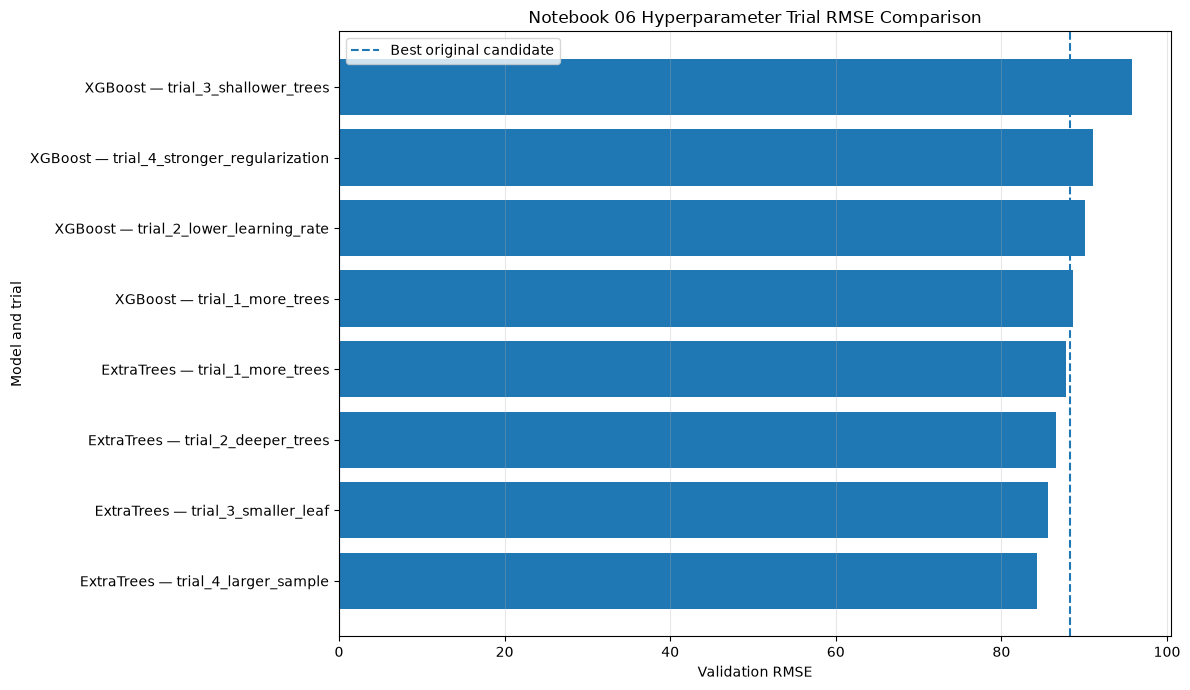

In [40]:
trial_labels = (
    ranked_trials_df["model"]
    + " — "
    + ranked_trials_df["trial"]
)

plt.figure(figsize=(12, 7))

plt.barh(
    trial_labels,
    ranked_trials_df["rmse"],
)

plt.axvline(
    optimization_candidates_df["rmse"].min(),
    linestyle="--",
    label="Best original candidate",
)

plt.xlabel("Validation RMSE")
plt.ylabel("Model and trial")
plt.title("Notebook 06 Hyperparameter Trial RMSE Comparison")
plt.legend()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

optimization_rmse_plot_path = (
    COMPARISON_PLOTS_DIR
    / "optimization_trial_rmse.png"
)

plt.savefig(
    optimization_rmse_plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

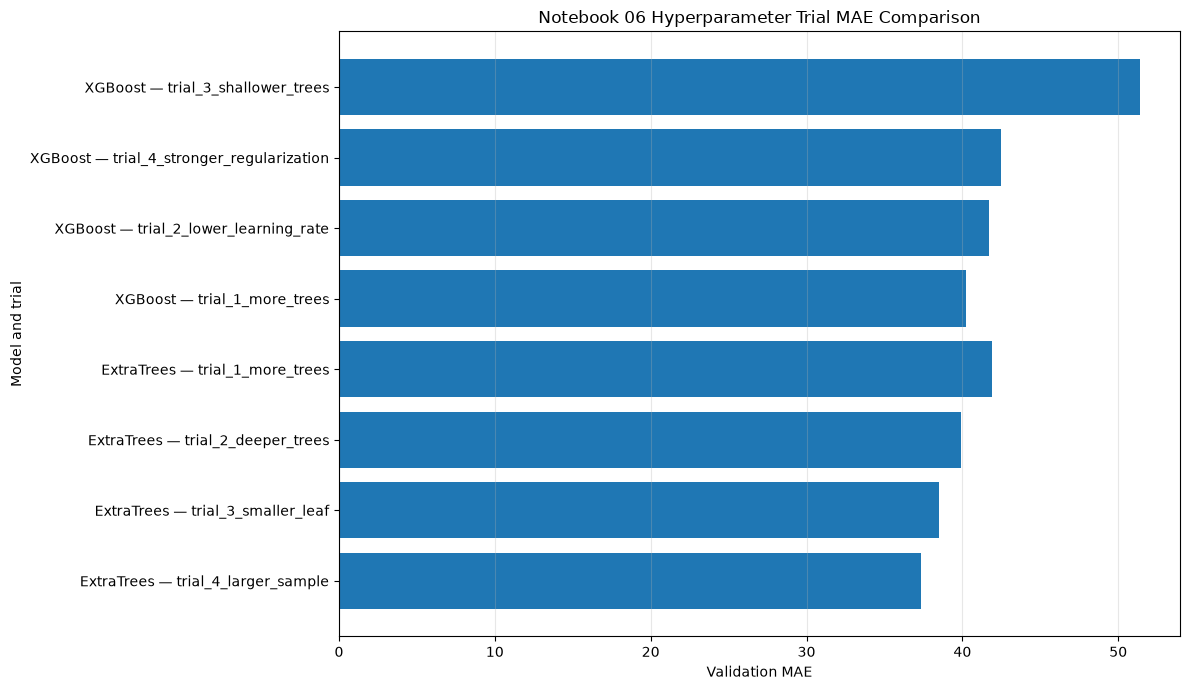

In [41]:
plt.figure(figsize=(12, 7))

plt.barh(
    trial_labels,
    ranked_trials_df["mae"],
)

plt.xlabel("Validation MAE")
plt.ylabel("Model and trial")
plt.title("Notebook 06 Hyperparameter Trial MAE Comparison")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

optimization_mae_plot_path = (
    COMPARISON_PLOTS_DIR
    / "optimization_trial_mae.png"
)

plt.savefig(
    optimization_mae_plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [43]:
print("Saved RMSE plot:", optimization_rmse_plot_path)
print("Saved MAE plot:", optimization_mae_plot_path)

Saved RMSE plot: ..\results\notebook_07\comparison_plots\optimization_trial_rmse.png
Saved MAE plot: ..\results\notebook_07\comparison_plots\optimization_trial_mae.png


### 18. Inspect Model Comparison Table Structures

Before combining results from Notebooks 04, 05, and 06, this section inspects their column structures.

The files may use different model-name or metric-column formats, so we first confirm the exact structure before standardizing them.

In [44]:
comparison_tables = {
    "Notebook 04 Baselines": baseline_summary_df,
    "Notebook 05 Models": model_comparison_df,
    "Notebook 06 Advanced Models": advanced_model_comparison_df,
    "Notebook 06 Final Optimized Models": final_optimized_comparison_df,
}

for table_name, dataframe in comparison_tables.items():
    print(f"\n{table_name}")
    print("=" * len(table_name))
    print("Shape:", dataframe.shape)
    print("Columns:", dataframe.columns.tolist())
    display(dataframe.head())


Notebook 04 Baselines
Shape: (6, 11)
Columns: ['Model', 'Mean RMSE', 'Median RMSE', 'RMSE Std', 'Mean MAE', 'Median MAE', 'MAE Std', 'Evaluated Wells', 'Rank', 'Winning Wells', 'Winning Percentage']


,Model,Mean RMSE,Median RMSE,RMSE Std,Mean MAE,Median MAE,MAE Std,Evaluated Wells,Rank,Winning Wells,Winning Percentage
0,Last Known TVT,12.8125,10.6651,8.8995,10.9323,8.7286,8.1367,773,1,599,77.4903
1,Linear Extrapolation (10),58.1355,37.2149,80.4469,49.3559,30.5816,69.1215,773,2,62,8.0207
2,Linear Extrapolation (100),60.1914,36.7085,91.0576,51.2812,32.1667,78.3628,773,3,59,7.6326
3,Linear Extrapolation (50),60.6829,37.9880,87.2597,51.6731,32.4676,75.0689,773,4,50,6.4683
4,Z → TVT Linear,110.8777,107.1353,41.3900,99.6183,96.2368,37.1761,773,5,3,0.3881



Notebook 05 Models
Shape: (2, 5)
Columns: ['Model', 'Mean RMSE', 'Std RMSE', 'Mean MAE', 'Std MAE']


,Model,Mean RMSE,Std RMSE,Mean MAE,Std MAE
0,Random Forest,103.6866,18.4787,48.5077,4.7310
1,Linear Regression,115.0839,12.7728,83.8426,5.6276



Notebook 06 Advanced Models
Shape: (4, 15)
Columns: ['model', 'rmse', 'mae', 'training_seconds', 'prediction_seconds', 'validation_rows', 'validation_wells', 'rmse_rank', 'mae_rank', 'training_time_rank', 'prediction_time_rank', 'overall_score', 'overall_rank', 'rmse_difference_from_best', 'rmse_percentage_above_best']


,model,rmse,mae,training_seconds,prediction_seconds,validation_rows,validation_wells,rmse_rank,mae_rank,training_time_rank,prediction_time_rank,overall_score,overall_rank,rmse_difference_from_best,rmse_percentage_above_best
0,ExtraTrees,88.2816,42.2443,77.1927,2.6890,1044037,155,1,1,3,1,1.2000,1,0.0000,0.0000
1,XGBoost,90.2238,42.2748,127.5099,3.7613,1044037,155,2,2,4,2,2.2000,2,1.9422,2.2001
2,LightGBM,94.3573,50.9537,72.4412,7.8270,1044037,155,3,4,2,3,3.2000,3,6.0758,6.8823
3,HistGradientBoosting,95.5980,50.8769,67.1292,7.8419,1044037,155,4,3,1,4,3.4000,4,7.3165,8.2877



Notebook 06 Final Optimized Models
Shape: (2, 4)
Columns: ['model', 'trial', 'rmse', 'mae']


,model,trial,rmse,mae
0,ExtraTrees,trial_4_larger_sample,84.2854,37.3521
1,XGBoost,trial_1_more_trees,88.6237,40.2255


### 19. Standardize Notebook 04 Baseline Results

Notebook 04 reports average well-level RMSE and MAE across all evaluated wells.

These metrics are renamed into a shared schema so they can be displayed alongside later machine-learning results.

Because the baseline metrics were calculated using a different validation structure, they should be interpreted as reference benchmarks rather than perfectly identical measurements.

In [45]:
baseline_comparison_df = (
    baseline_summary_df[
        [
            "Model",
            "Mean RMSE",
            "Mean MAE",
            "RMSE Std",
            "MAE Std",
            "Evaluated Wells",
        ]
    ]
    .rename(
        columns={
            "Model": "model",
            "Mean RMSE": "rmse",
            "Mean MAE": "mae",
            "RMSE Std": "rmse_std",
            "MAE Std": "mae_std",
            "Evaluated Wells": "evaluated_wells",
        }
    )
    .copy()
)

baseline_comparison_df["source_notebook"] = "Notebook 04"
baseline_comparison_df["model_category"] = "Baseline"
baseline_comparison_df["model_variant"] = "Original"
baseline_comparison_df["evaluation_method"] = (
    "Mean well-level performance"
)

baseline_comparison_df

,model,rmse,mae,rmse_std,mae_std,evaluated_wells,source_notebook,model_category,model_variant,evaluation_method
0,Last Known TVT,12.8125,10.9323,8.8995,8.1367,773,Notebook 04,Baseline,Original,Mean well-level performance
1,Linear Extrapolation (10),58.1355,49.3559,80.4469,69.1215,773,Notebook 04,Baseline,Original,Mean well-level performance
2,Linear Extrapolation (100),60.1914,51.2812,91.0576,78.3628,773,Notebook 04,Baseline,Original,Mean well-level performance
3,Linear Extrapolation (50),60.6829,51.6731,87.2597,75.0689,773,Notebook 04,Baseline,Original,Mean well-level performance
4,Z → TVT Linear,110.8777,99.6183,41.3900,37.1761,773,Notebook 04,Baseline,Original,Mean well-level performance
5,Formation Marker,1017.9323,903.6561,676.5793,592.5908,773,Notebook 04,Baseline,Original,Mean well-level performance


### 20. Standardize Notebook 05 Machine-Learning Results

Notebook 05 contains GroupKFold validation summaries for Linear Regression and Random Forest.

Their metric names are standardized while preserving cross-validation variability.

In [46]:
notebook_05_comparison_df = (
    model_comparison_df[
        [
            "Model",
            "Mean RMSE",
            "Mean MAE",
            "Std RMSE",
            "Std MAE",
        ]
    ]
    .rename(
        columns={
            "Model": "model",
            "Mean RMSE": "rmse",
            "Mean MAE": "mae",
            "Std RMSE": "rmse_std",
            "Std MAE": "mae_std",
        }
    )
    .copy()
)

notebook_05_comparison_df["evaluated_wells"] = np.nan
notebook_05_comparison_df["source_notebook"] = "Notebook 05"
notebook_05_comparison_df["model_category"] = "Machine Learning"
notebook_05_comparison_df["model_variant"] = "Initial"
notebook_05_comparison_df["evaluation_method"] = "GroupKFold"

notebook_05_comparison_df

,model,rmse,mae,rmse_std,mae_std,evaluated_wells,source_notebook,model_category,model_variant,evaluation_method
0,Random Forest,103.6866,48.5077,18.4787,4.7310,NaN,Notebook 05,Machine Learning,Initial,GroupKFold
1,Linear Regression,115.0839,83.8426,12.7728,5.6276,NaN,Notebook 05,Machine Learning,Initial,GroupKFold


### 21. Standardize Notebook 06 Advanced and Optimized Results

Notebook 06 evaluated four advanced models and then optimized Extra Trees and XGBoost.

Both the original candidates and their optimized versions are retained so that the effect of hyperparameter tuning remains visible in the final comparison.

In [47]:
notebook_06_original_df = (
    advanced_model_comparison_df[
        [
            "model",
            "rmse",
            "mae",
            "validation_wells",
        ]
    ]
    .rename(
        columns={
            "validation_wells": "evaluated_wells",
        }
    )
    .copy()
)

notebook_06_original_df["rmse_std"] = np.nan
notebook_06_original_df["mae_std"] = np.nan
notebook_06_original_df["source_notebook"] = "Notebook 06"
notebook_06_original_df["model_category"] = "Advanced ML"
notebook_06_original_df["model_variant"] = "Original"
notebook_06_original_df["evaluation_method"] = (
    "Held-out validation wells"
)

notebook_06_original_df

,model,rmse,mae,evaluated_wells,rmse_std,mae_std,source_notebook,model_category,model_variant,evaluation_method
0,ExtraTrees,88.2816,42.2443,155,NaN,NaN,Notebook 06,Advanced ML,Original,Held-out validation wells
1,XGBoost,90.2238,42.2748,155,NaN,NaN,Notebook 06,Advanced ML,Original,Held-out validation wells
2,LightGBM,94.3573,50.9537,155,NaN,NaN,Notebook 06,Advanced ML,Original,Held-out validation wells
3,HistGradientBoosting,95.5980,50.8769,155,NaN,NaN,Notebook 06,Advanced ML,Original,Held-out validation wells


In [48]:
notebook_06_optimized_df = (
    final_optimized_comparison_df[
        [
            "model",
            "trial",
            "rmse",
            "mae",
        ]
    ]
    .copy()
)

notebook_06_optimized_df["model"] = (
    notebook_06_optimized_df["model"]
    + " — Optimized"
)

notebook_06_optimized_df["model_variant"] = (
    notebook_06_optimized_df["trial"]
)

notebook_06_optimized_df = (
    notebook_06_optimized_df
    .drop(columns=["trial"])
)

notebook_06_optimized_df["rmse_std"] = np.nan
notebook_06_optimized_df["mae_std"] = np.nan
notebook_06_optimized_df["evaluated_wells"] = 155
notebook_06_optimized_df["source_notebook"] = "Notebook 06"
notebook_06_optimized_df["model_category"] = "Optimized ML"
notebook_06_optimized_df["evaluation_method"] = (
    "Held-out validation wells"
)

notebook_06_optimized_df

,model,rmse,mae,model_variant,rmse_std,mae_std,evaluated_wells,source_notebook,model_category,evaluation_method
0,ExtraTrees — Optimized,84.2854,37.3521,trial_4_larger_sample,NaN,NaN,155,Notebook 06,Optimized ML,Held-out validation wells
1,XGBoost — Optimized,88.6237,40.2255,trial_1_more_trees,NaN,NaN,155,Notebook 06,Optimized ML,Held-out validation wells


### 22. Create Unified Model Comparison Table

All baseline, initial machine-learning, advanced, and optimized model summaries are combined into one table.

RMSE is used as the primary sorting metric because it is the official Kaggle competition metric.

In [49]:
comparison_columns = [
    "model",
    "rmse",
    "mae",
    "rmse_std",
    "mae_std",
    "evaluated_wells",
    "source_notebook",
    "model_category",
    "model_variant",
    "evaluation_method",
]

unified_model_comparison_df = pd.concat(
    [
        baseline_comparison_df[comparison_columns],
        notebook_05_comparison_df[comparison_columns],
        notebook_06_original_df[comparison_columns],
        notebook_06_optimized_df[comparison_columns],
    ],
    ignore_index=True,
)

unified_model_comparison_df = (
    unified_model_comparison_df
    .sort_values(
        by=["rmse", "mae"],
        ascending=[True, True],
    )
    .reset_index(drop=True)
)

unified_model_comparison_df["historical_display_order"] = (
    np.arange(1, len(unified_model_comparison_df) + 1)
)

unified_model_comparison_df[
    [
        "historical_display_order",
        "model",
        "rmse",
        "mae",
        "source_notebook",
        "model_category",
        "evaluation_method",
    ]
]

,historical_display_order,model,rmse,mae,source_notebook,model_category,evaluation_method
0,1,Last Known TVT,12.8125,10.9323,Notebook 04,Baseline,Mean well-level performance
1,2,Linear Extrapolation (10),58.1355,49.3559,Notebook 04,Baseline,Mean well-level performance
2,3,Linear Extrapolation (100),60.1914,51.2812,Notebook 04,Baseline,Mean well-level performance
3,4,Linear Extrapolation (50),60.6829,51.6731,Notebook 04,Baseline,Mean well-level performance
4,5,ExtraTrees — Optimized,84.2854,37.3521,Notebook 06,Optimized ML,Held-out validation wells
5,6,ExtraTrees,88.2816,42.2443,Notebook 06,Advanced ML,Held-out validation wells
6,7,XGBoost — Optimized,88.6237,40.2255,Notebook 06,Optimized ML,Held-out validation wells
7,8,XGBoost,90.2238,42.2748,Notebook 06,Advanced ML,Held-out validation wells
8,9,LightGBM,94.3573,50.9537,Notebook 06,Advanced ML,Held-out validation wells
9,10,HistGradientBoosting,95.5980,50.8769,Notebook 06,Advanced ML,Held-out validation wells


> **Important:** The historical display order is based on the reported RMSE values, but it is not the final model ranking because the models were evaluated using different validation procedures. Final selection will use results obtained under a consistent validation framework.

### 23. Define Final Unified Validation Protocol

Notebook 06 used a single 80/20 group-aware holdout split for model development and hyperparameter optimization.

Because the same 155 validation wells were repeatedly used to compare configurations, those results represent development estimates rather than fully independent final-validation results.

Notebook 07 therefore uses GroupKFold cross-validation as the final unified evaluation framework.

All candidate models will:

- Use the same processed dataset.
- Use the same 24 feature columns.
- Predict the same TVT target.
- Use well_id as the grouping variable.
- Be evaluated on identical validation folds.
- Be ranked primarily using mean out-of-fold RMSE.
- Use MAE and fold-level variability as supporting metrics.

#### 23.1 Configure GroupKFold

In [50]:
FINAL_CV_SPLITS = 5

final_group_kfold = GroupKFold(
    n_splits=FINAL_CV_SPLITS
)

print("Final validation method: GroupKFold")
print("Number of folds:", FINAL_CV_SPLITS)
print("Number of rows:", len(X))
print("Number of unique wells:", groups.nunique())

Final validation method: GroupKFold
Number of folds: 5
Number of rows: 5092255
Number of unique wells: 773


#### 23.2 Inspect Fold Sizes and Well Separation

In [51]:
final_cv_fold_rows = []

for fold_number, (
    train_indices,
    validation_indices,
) in enumerate(
    final_group_kfold.split(
        X,
        y,
        groups=groups,
    ),
    start=1,
):

    train_groups = set(
        groups.iloc[train_indices]
    )

    validation_groups = set(
        groups.iloc[validation_indices]
    )

    overlapping_wells = (
        train_groups.intersection(
            validation_groups
        )
    )

    final_cv_fold_rows.append({
        "fold": fold_number,
        "training_rows": len(train_indices),
        "validation_rows": len(validation_indices),
        "training_wells": len(train_groups),
        "validation_wells": len(validation_groups),
        "overlapping_wells": len(overlapping_wells),
    })

final_cv_structure_df = pd.DataFrame(
    final_cv_fold_rows
)

final_cv_structure_df

,fold,training_rows,validation_rows,training_wells,validation_wells,overlapping_wells
0,1,4075197,1017058,619,154,0
1,2,4075198,1017057,619,154,0
2,3,4073152,1019103,618,155,0
3,4,4072802,1019453,618,155,0
4,5,4072671,1019584,618,155,0


In [52]:
assert (
    final_cv_structure_df["overlapping_wells"] == 0
).all(), "Well leakage detected between training and validation sets."

assert (
    final_cv_structure_df["validation_wells"].sum()
    == groups.nunique()
), "Some wells were not assigned correctly across validation folds."

print(
    "GroupKFold structure validated successfully. "
    "No wells overlap between training and validation."
)

GroupKFold structure validated successfully. No wells overlap between training and validation.


#### 23.3 Record the Validation Strategy

In [53]:
final_validation_protocol = {
    "validation_method": "GroupKFold",
    "n_splits": FINAL_CV_SPLITS,
    "group_column": "well_id",
    "target_column": "TVT",
    "primary_metric": "RMSE",
    "secondary_metric": "MAE",
    "number_of_rows": int(len(X)),
    "number_of_wells": int(groups.nunique()),
    "number_of_features": int(len(feature_columns)),
}

final_validation_protocol

{'validation_method': 'GroupKFold',
 'n_splits': 5,
 'group_column': 'well_id',
 'target_column': 'TVT',
 'primary_metric': 'RMSE',
 'secondary_metric': 'MAE',
 'number_of_rows': 5092255,
 'number_of_wells': 773,
 'number_of_features': 24}

### 24. Inspect Reusable Project Modules

Before rebuilding candidate models, the reusable modules inside `src/` are inspected.

Notebook 07 should import existing model factories, evaluation functions, and configuration constants wherever possible instead of duplicating logic from earlier notebooks.

In [54]:
SRC_DIR = PROJECT_ROOT / "src"

if not SRC_DIR.exists():
    raise FileNotFoundError(
        f"Source directory not found: {SRC_DIR}"
    )

src_files = sorted(
    file_path
    for file_path in SRC_DIR.rglob("*.py")
    if "__pycache__" not in file_path.parts
)

src_files_df = pd.DataFrame({
    "module_path": [
        str(path.relative_to(PROJECT_ROOT))
        for path in src_files
    ],
    "size_kb": [
        round(path.stat().st_size / 1024, 2)
        for path in src_files
    ],
})

src_files_df

,module_path,size_kb
0,src\__init__.py,0.0000
1,src\config.py,1.1600
2,src\data_loader.py,4.5300
3,src\evaluation.py,4.1500
4,src\feature_engineering.py,1.9500
5,src\models.py,5.9900


In [55]:
import ast

src_symbols = []

for file_path in src_files:
    source_text = file_path.read_text(
        encoding="utf-8"
    )

    parsed_module = ast.parse(source_text)

    for node in parsed_module.body:
        if isinstance(
            node,
            (
                ast.FunctionDef,
                ast.AsyncFunctionDef,
                ast.ClassDef,
            ),
        ):
            if not node.name.startswith("_"):
                src_symbols.append({
                    "module": str(
                        file_path.relative_to(PROJECT_ROOT)
                    ),
                    "symbol": node.name,
                    "type": (
                        "class"
                        if isinstance(node, ast.ClassDef)
                        else "function"
                    ),
                })

src_symbols_df = pd.DataFrame(src_symbols)

src_symbols_df

,module,symbol,type
0,src\config.py,create_project_directories,function
1,src\data_loader.py,discover_training_wells,function
2,src\data_loader.py,discover_test_wells,function
3,src\data_loader.py,discover_test_well_pairs,function
4,src\data_loader.py,load_typewell,function
5,src\data_loader.py,load_horizontal_well,function
6,src\data_loader.py,load_training_pair,function
7,src\data_loader.py,load_test_horizontal_well,function
8,src\data_loader.py,load_test_typewell,function
9,src\data_loader.py,load_test_pair,function


### 25. Inspect Saved Model Pipelines

The saved models are inspected to identify their estimator types, preprocessing steps, and trained hyperparameters.

This allows Notebook 07 to reconstruct equivalent unfitted models for GroupKFold validation without assuming their configurations.

In [56]:
saved_models = {
    "Linear Regression": linear_regression_model,
    "Random Forest": random_forest_model,
    "Optimized Extra Trees": optimized_pipeline,
}

for model_name, saved_model in saved_models.items():
    print(f"\n{model_name}")
    print("=" * len(model_name))
    print("Object type:", type(saved_model))

    if hasattr(saved_model, "steps"):
        print("Pipeline steps:")

        for step_name, step_object in saved_model.steps:
            print(
                f"- {step_name}: "
                f"{type(step_object).__name__}"
            )

    else:
        print(
            "Estimator class:",
            type(saved_model).__name__,
        )


Linear Regression
Object type: <class 'sklearn.pipeline.Pipeline'>
Pipeline steps:
- preprocessor: ColumnTransformer
- model: LinearRegression

Random Forest
Object type: <class 'sklearn.pipeline.Pipeline'>
Pipeline steps:
- preprocessor: ColumnTransformer
- model: RandomForestRegressor

Optimized Extra Trees
Object type: <class 'sklearn.pipeline.Pipeline'>
Pipeline steps:
- preprocessor: ColumnTransformer
- model: ExtraTreesRegressor


In [57]:
for model_name, saved_model in saved_models.items():
    print(f"\n{model_name}")
    print("=" * len(model_name))

    model_parameters = saved_model.get_params(
        deep=True
    )

    display(
        pd.DataFrame(
            {
                "parameter": model_parameters.keys(),
                "value": model_parameters.values(),
            }
        )
    )


Linear Regression


,parameter,value
0,memory,None
1,steps,"[(preprocessor, ColumnTransformer(transformers..."
2,transform_input,None
3,verbose,False
4,preprocessor,"ColumnTransformer(transformers=[('numeric',\n ..."
5,model,LinearRegression()
6,preprocessor__n_jobs,None
7,preprocessor__remainder,drop
8,preprocessor__sparse_threshold,0.3000
9,preprocessor__transformer_weights,None



Random Forest


,parameter,value
0,memory,None
1,steps,"[(preprocessor, ColumnTransformer(transformers..."
2,transform_input,None
3,verbose,False
4,preprocessor,"ColumnTransformer(transformers=[('numeric',\n ..."
5,model,"(DecisionTreeRegressor(max_depth=18, max_featu..."
6,preprocessor__n_jobs,None
7,preprocessor__remainder,drop
8,preprocessor__sparse_threshold,0.3000
9,preprocessor__transformer_weights,None



Optimized Extra Trees


,parameter,value
0,memory,None
1,steps,"[(preprocessor, ColumnTransformer(transformers..."
2,transform_input,None
3,verbose,False
4,preprocessor,"ColumnTransformer(transformers=[('numeric',\n ..."
5,model,"(ExtraTreeRegressor(max_depth=20, min_samples_..."
6,preprocessor__n_jobs,None
7,preprocessor__remainder,drop
8,preprocessor__sparse_threshold,0.3000
9,preprocessor__transformer_weights,None


### 26. Inspect the Optimized XGBoost Configuration

Notebook 06 identified an optimized XGBoost trial, but only the winning Extra Trees pipeline was saved as the final optimized model.

The stored trial parameters are inspected so that an equivalent XGBoost candidate can be reconstructed using reusable project code.

In [50]:
optimized_xgboost_trial_df = (
    all_trials_df[
        (all_trials_df["model"] == "XGBoost")
        & (
            all_trials_df["trial"]
            == "trial_1_more_trees"
        )
    ]
    .copy()
)

if len(optimized_xgboost_trial_df) != 1:
    raise ValueError(
        "Expected exactly one optimized "
        "XGBoost trial record."
    )

optimized_xgboost_trial_df

,model,trial,rmse,mae,training_seconds,prediction_seconds,parameters
4,XGBoost,trial_1_more_trees,88.6237,40.2255,212.0143,5.3949,"{""n_estimators"": 500}"


In [59]:
optimized_xgboost_parameters = json.loads(
    optimized_xgboost_trial_df.iloc[0][
        "parameters"
    ]
)

optimized_xgboost_parameters

{'n_estimators': 500}

### 27. Build the Final Candidate Model Registry

The candidate models are prepared as fresh, unfitted pipelines for final GroupKFold evaluation.

Cloning preserves the preprocessing and hyperparameter configurations of the saved pipelines while removing their fitted state.

The optimized XGBoost candidate is recreated using the reusable model factory from `src/models.py`.

#### 27.1 Load src/models.py Directly

In [51]:
import importlib.util
import sys

models_module_path = (
    PROJECT_ROOT
    / "src"
    / "models.py"
).resolve()

if not models_module_path.exists():
    raise FileNotFoundError(
        f"models.py not found at: {models_module_path}"
    )

module_spec = importlib.util.spec_from_file_location(
    "project_models",
    models_module_path,
)

project_models = importlib.util.module_from_spec(
    module_spec
)

sys.modules["project_models"] = project_models

module_spec.loader.exec_module(
    project_models
)

print(
    "Loaded model module from:",
    models_module_path,
)

Loaded model module from: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\src\models.py


In [64]:
required_model_factories = [
    "create_linear_regression_pipeline",
    "create_random_forest_pipeline",
    "create_hist_gradient_boosting_pipeline",
    "create_extra_trees_pipeline",
    "create_xgboost_pipeline",
]

for factory_name in required_model_factories:
    print(
        factory_name,
        hasattr(project_models, factory_name),
    )

create_linear_regression_pipeline True
create_random_forest_pipeline True
create_hist_gradient_boosting_pipeline True
create_extra_trees_pipeline True
create_xgboost_pipeline True


#### 27.2 Inspect the XGBoost Factory Signature

In [65]:
import inspect

xgboost_factory_signature = inspect.signature(
    project_models.create_xgboost_pipeline
)

print(
    "XGBoost factory signature:",
    xgboost_factory_signature,
)

XGBoost factory signature: (feature_columns: collections.abc.Sequence[str], model_params: collections.abc.Mapping[str, Any] | None = None) -> sklearn.pipeline.Pipeline


In [66]:
print(
    inspect.getsource(
        project_models.create_xgboost_pipeline
    )
)

def create_xgboost_pipeline(
    feature_columns: Sequence[str],
    model_params: Mapping[str, Any] | None = None,
) -> Pipeline:
    """
    Create a memory-conscious XGBoost regression pipeline.

    Custom model parameters can be supplied for optimization trials.
    """

    preprocessor = create_preprocessor(
        feature_columns=feature_columns,
        scale_features=False,
    )

    default_params = {
        "objective": "reg:squarederror",
        "n_estimators": 300,
        "learning_rate": 0.05,
        "max_depth": 8,
        "min_child_weight": 20,
        "subsample": 0.50,
        "colsample_bytree": 0.80,
        "reg_alpha": 0.10,
        "reg_lambda": 1.00,
        "tree_method": "hist",
        "max_bin": 256,
        "random_state": 42,
        "n_jobs": 4,
        "verbosity": 1,
    }

    if model_params is not None:
        default_params.update(model_params)

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
 

#### 27.3 Clone the Saved Candidate Pipelines

In [52]:
from sklearn.base import clone

linear_regression_candidate = clone(
    linear_regression_model
)

random_forest_candidate = clone(
    random_forest_model
)

optimized_extra_trees_candidate = clone(
    optimized_pipeline
)

In [68]:
cloned_candidates = {
    "Linear Regression": (
        linear_regression_candidate
    ),
    "Random Forest": (
        random_forest_candidate
    ),
    "Extra Trees Optimized": (
        optimized_extra_trees_candidate
    ),
}

for model_name, pipeline in cloned_candidates.items():
    estimator = pipeline.named_steps["model"]

    print(
        f"{model_name}: "
        f"{type(estimator).__name__}"
    )

Linear Regression: LinearRegression
Random Forest: RandomForestRegressor
Extra Trees Optimized: ExtraTreesRegressor


#### 27.4 Recreate the Optimized XGBoost Pipeline

In [69]:
optimized_xgboost_parameters

{'n_estimators': 500}

In [70]:
optimized_xgboost_candidate = (
    project_models.create_xgboost_pipeline(
        feature_columns
    )
)

In [71]:
optimized_xgboost_candidate.set_params(
    model__n_estimators=(
        optimized_xgboost_parameters[
            "n_estimators"
        ]
    )
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of

#### 27.5 Verify the XGBoost Configuration

In [72]:
xgboost_estimator = (
    optimized_xgboost_candidate.named_steps[
        "model"
    ]
)

xgboost_parameters = (
    xgboost_estimator.get_params()
)

xgboost_configuration_df = pd.DataFrame({
    "parameter": [
        "n_estimators",
        "max_depth",
        "learning_rate",
        "subsample",
        "colsample_bytree",
        "objective",
        "random_state",
        "n_jobs",
    ],
    "value": [
        xgboost_parameters.get(
            "n_estimators"
        ),
        xgboost_parameters.get(
            "max_depth"
        ),
        xgboost_parameters.get(
            "learning_rate"
        ),
        xgboost_parameters.get(
            "subsample"
        ),
        xgboost_parameters.get(
            "colsample_bytree"
        ),
        xgboost_parameters.get(
            "objective"
        ),
        xgboost_parameters.get(
            "random_state"
        ),
        xgboost_parameters.get(
            "n_jobs"
        ),
    ],
})

xgboost_configuration_df

,parameter,value
0,n_estimators,500
1,max_depth,8
2,learning_rate,0.0500
3,subsample,0.5000
4,colsample_bytree,0.8000
5,objective,reg:squarederror
6,random_state,42
7,n_jobs,4


#### 27.6 Create the Final Candidate Registry

In [77]:
final_candidate_models = {
    "Linear Regression": (
        linear_regression_candidate
    ),
    "Random Forest": (
        random_forest_candidate
    ),
    "Extra Trees Optimized": (
        optimized_extra_trees_candidate
    ),
    "XGBoost Optimized": (
        optimized_xgboost_candidate
    ),

}


In [74]:
candidate_registry_rows = []

for model_name, pipeline in (
    final_candidate_models.items()
):
    estimator = pipeline.named_steps["model"]
    parameters = estimator.get_params()

    candidate_registry_rows.append({
        "model": model_name,
        "estimator": (
            type(estimator).__name__
        ),
        "n_estimators": (
            parameters.get(
                "n_estimators"
            )
        ),
        "max_depth": (
            parameters.get(
                "max_depth"
            )
        ),
        "min_samples_leaf": (
            parameters.get(
                "min_samples_leaf"
            )
        ),
        "max_samples": (
            parameters.get(
                "max_samples"
            )
        ),
        "learning_rate": (
            parameters.get(
                "learning_rate"
            )
        ),
        "random_state": (
            parameters.get(
                "random_state"
            )
        ),
        "n_jobs": (
            parameters.get(
                "n_jobs"
            )
        ),
    })

final_candidate_registry_df = pd.DataFrame(
    candidate_registry_rows
)

final_candidate_registry_df

,model,estimator,n_estimators,max_depth,min_samples_leaf,max_samples,learning_rate,random_state,n_jobs
0,Linear Regression,LinearRegression,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Random Forest,RandomForestRegressor,100.0000,18.0000,50.0000,0.1000,NaN,42.0000,4.0000
2,Extra Trees Optimized,ExtraTreesRegressor,150.0000,20.0000,25.0000,0.2000,NaN,42.0000,4.0000
3,XGBoost Optimized,XGBRegressor,500.0000,8.0000,NaN,NaN,0.0500,42.0000,4.0000


#### 27.7 Save the Candidate Registry

In [75]:
candidate_registry_path = (
    NOTEBOOK_07_RESULTS_DIR
    / "final_candidate_registry.csv"
)

final_candidate_registry_df.to_csv(
    candidate_registry_path,
    index=False,
)

print(
    "Candidate registry saved to:",
    candidate_registry_path,
)

Candidate registry saved to: ..\results\notebook_07\final_candidate_registry.csv


##### Final Candidate Selection Rationale

The final unified validation compares four representative models.

- Linear Regression provides a simple regression benchmark.
- Random Forest represents the first tree-based ensemble developed in Notebook 05.
- Optimized Extra Trees represents the best-performing model from Notebook 06.
- Optimized XGBoost represents the strongest gradient-boosting candidate.

Earlier baselines remain part of the historical comparison, while unsuccessful or weaker hyperparameter trials are not repeated. Only the selected configuration from each important model family is evaluated using the final GroupKFold protocol.

### 28. Build the GroupKFold Evaluation Function

A reusable evaluation function is created to assess every final candidate model under the same GroupKFold validation protocol.

For each fold, the function:

- Creates a fresh clone of the candidate pipeline.
- Trains only on the training wells.
- Predicts the validation wells.
- Calculates RMSE and MAE.
- Records training and prediction durations.
- Stores out-of-fold predictions.
- Confirms that no well appears in both training and validation.

The combined out-of-fold predictions will later be used for final model ranking, per-well analysis, residual analysis, and ensemble construction.

#### 28.1 Import Required Utilities

In [78]:
from time import perf_counter

from sklearn.base import clone
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
)
from sklearn.model_selection import GroupKFold

#### 28.2 Create the Evaluation Function

In [79]:
def evaluate_model_group_kfold(
    model,
    model_name,
    X,
    y,
    groups,
    n_splits=5,
    verbose=True,
):
    """
    Evaluate a regression pipeline using GroupKFold.

    Parameters
    ----------
    model : sklearn-compatible estimator or pipeline
        Unfitted candidate model.

    model_name : str
        Human-readable model name.

    X : pandas.DataFrame
        Feature matrix.

    y : pandas.Series
        Regression target.

    groups : pandas.Series
        Well identifiers used to prevent leakage.

    n_splits : int, default=5
        Number of GroupKFold folds.

    verbose : bool, default=True
        Whether to print fold progress.

    Returns
    -------
    dict
        Contains:

        - summary: overall out-of-fold metrics
        - fold_metrics: one row per fold
        - predictions: row-level out-of-fold predictions
    """

    if not (
        len(X)
        == len(y)
        == len(groups)
    ):
        raise ValueError(
            "X, y, and groups must have "
            "the same number of rows."
        )

    if groups.nunique() < n_splits:
        raise ValueError(
            "The number of unique groups must be "
            "at least equal to n_splits."
        )

    group_kfold = GroupKFold(
        n_splits=n_splits
    )

    fold_metric_rows = []
    prediction_frames = []

    total_start_time = perf_counter()

    for fold_number, (
        train_indices,
        validation_indices,
    ) in enumerate(
        group_kfold.split(
            X,
            y,
            groups=groups,
        ),
        start=1,
    ):
        if verbose:
            print(
                f"\n{model_name} — Fold "
                f"{fold_number}/{n_splits}"
            )

        X_train_fold = X.iloc[
            train_indices
        ]

        X_validation_fold = X.iloc[
            validation_indices
        ]

        y_train_fold = y.iloc[
            train_indices
        ]

        y_validation_fold = y.iloc[
            validation_indices
        ]

        training_groups = set(
            groups.iloc[
                train_indices
            ]
        )

        validation_groups = set(
            groups.iloc[
                validation_indices
            ]
        )

        overlapping_groups = (
            training_groups.intersection(
                validation_groups
            )
        )

        if overlapping_groups:
            raise ValueError(
                f"Group leakage detected in "
                f"fold {fold_number}."
            )

        fold_model = clone(model)

        training_start_time = (
            perf_counter()
        )

        fold_model.fit(
            X_train_fold,
            y_train_fold,
        )

        training_seconds = (
            perf_counter()
            - training_start_time
        )

        prediction_start_time = (
            perf_counter()
        )

        validation_predictions = (
            fold_model.predict(
                X_validation_fold
            )
        )

        prediction_seconds = (
            perf_counter()
            - prediction_start_time
        )

        fold_rmse = np.sqrt(
            mean_squared_error(
                y_validation_fold,
                validation_predictions,
            )
        )

        fold_mae = mean_absolute_error(
            y_validation_fold,
            validation_predictions,
        )

        fold_metric_rows.append({
            "model": model_name,
            "fold": fold_number,
            "rmse": fold_rmse,
            "mae": fold_mae,
            "training_seconds": (
                training_seconds
            ),
            "prediction_seconds": (
                prediction_seconds
            ),
            "training_rows": (
                len(train_indices)
            ),
            "validation_rows": (
                len(validation_indices)
            ),
            "training_wells": (
                len(training_groups)
            ),
            "validation_wells": (
                len(validation_groups)
            ),
            "overlapping_wells": (
                len(overlapping_groups)
            ),
        })

        fold_predictions_df = pd.DataFrame({
            "row_index": (
                X_validation_fold.index
            ),
            "well_id": (
                groups.iloc[
                    validation_indices
                ].values
            ),
            "actual_tvt": (
                y_validation_fold.values
            ),
            "predicted_tvt": (
                validation_predictions
            ),
            "fold": fold_number,
            "model": model_name,
        })

        fold_predictions_df[
            "residual"
        ] = (
            fold_predictions_df[
                "actual_tvt"
            ]
            - fold_predictions_df[
                "predicted_tvt"
            ]
        )

        prediction_frames.append(
            fold_predictions_df
        )

        if verbose:
            print(
                f"Training wells: "
                f"{len(training_groups):,}"
            )

            print(
                f"Validation wells: "
                f"{len(validation_groups):,}"
            )

            print(
                f"Validation rows: "
                f"{len(validation_indices):,}"
            )

            print(
                f"RMSE: {fold_rmse:.4f}"
            )

            print(
                f"MAE: {fold_mae:.4f}"
            )

            print(
                f"Training time: "
                f"{training_seconds:.2f} seconds"
            )

            print(
                f"Prediction time: "
                f"{prediction_seconds:.2f} seconds"
            )

        del fold_model
        del X_train_fold
        del X_validation_fold
        del y_train_fold
        del y_validation_fold

    total_seconds = (
        perf_counter()
        - total_start_time
    )

    fold_metrics_df = pd.DataFrame(
        fold_metric_rows
    )

    out_of_fold_predictions_df = (
        pd.concat(
            prediction_frames,
            ignore_index=True,
        )
    )

    out_of_fold_predictions_df = (
        out_of_fold_predictions_df.sort_values(
            "row_index"
        ).reset_index(
            drop=True
        )
    )

    overall_rmse = np.sqrt(
        mean_squared_error(
            out_of_fold_predictions_df[
                "actual_tvt"
            ],
            out_of_fold_predictions_df[
                "predicted_tvt"
            ],
        )
    )

    overall_mae = mean_absolute_error(
        out_of_fold_predictions_df[
            "actual_tvt"
        ],
        out_of_fold_predictions_df[
            "predicted_tvt"
        ],
    )

    summary_df = pd.DataFrame([
        {
            "model": model_name,
            "validation_method": (
                f"{n_splits}-Fold GroupKFold"
            ),
            "oof_rmse": overall_rmse,
            "oof_mae": overall_mae,
            "mean_fold_rmse": (
                fold_metrics_df[
                    "rmse"
                ].mean()
            ),
            "std_fold_rmse": (
                fold_metrics_df[
                    "rmse"
                ].std()
            ),
            "mean_fold_mae": (
                fold_metrics_df[
                    "mae"
                ].mean()
            ),
            "std_fold_mae": (
                fold_metrics_df[
                    "mae"
                ].std()
            ),
            "total_training_seconds": (
                fold_metrics_df[
                    "training_seconds"
                ].sum()
            ),
            "total_prediction_seconds": (
                fold_metrics_df[
                    "prediction_seconds"
                ].sum()
            ),
            "total_evaluation_seconds": (
                total_seconds
            ),
            "evaluated_rows": (
                len(
                    out_of_fold_predictions_df
                )
            ),
            "evaluated_wells": (
                out_of_fold_predictions_df[
                    "well_id"
                ].nunique()
            ),
        }
    ])

    if (
        out_of_fold_predictions_df[
            "row_index"
        ].nunique()
        != len(X)
    ):
        raise ValueError(
            "The out-of-fold predictions do not "
            "contain exactly one prediction per row."
        )

    if verbose:
        print(
            f"\nCompleted {model_name}"
        )

        print(
            f"Overall OOF RMSE: "
            f"{overall_rmse:.4f}"
        )

        print(
            f"Overall OOF MAE: "
            f"{overall_mae:.4f}"
        )

        print(
            f"Total evaluation time: "
            f"{total_seconds:.2f} seconds"
        )

    return {
        "summary": summary_df,
        "fold_metrics": fold_metrics_df,
        "predictions": (
            out_of_fold_predictions_df
        ),
    }

#### 28.3 Important Metric Difference

The final models will be ranked primarily by overall out-of-fold RMSE.

Mean fold RMSE and its standard deviation are retained as supporting measures of cross-validation stability. MAE is used as the secondary error metric.

#### 28.4 Run a Small Structural Test

In [53]:
test_well_ids = (
    groups.drop_duplicates()
    .iloc[:20]
)

test_mask = groups.isin(
    test_well_ids
)

X_function_test = (
    X.loc[test_mask]
    .reset_index(drop=True)
)

y_function_test = (
    y.loc[test_mask]
    .reset_index(drop=True)
)

groups_function_test = (
    groups.loc[test_mask]
    .reset_index(drop=True)
)

print(
    "Test rows:",
    len(X_function_test),
)

print(
    "Test wells:",
    groups_function_test.nunique(),
)

Test rows: 124414
Test wells: 20


In [58]:
group_kfold_function_test = (
    evaluate_model_group_kfold(
        model=(
            linear_regression_candidate
        ),
        model_name=(
            "Linear Regression Test"
        ),
        X=X_function_test,
        y=y_function_test,
        groups=groups_function_test,
        n_splits=2,
        verbose=True,
    )
)

NameError: name 'evaluate_model_group_kfold' is not defined

In [83]:
group_kfold_function_test[
    "summary"
]

,model,validation_method,oof_rmse,oof_mae,mean_fold_rmse,std_fold_rmse,mean_fold_mae,std_fold_mae,total_training_seconds,total_prediction_seconds,total_evaluation_seconds,evaluated_rows,evaluated_wells
0,Linear Regression Test,2-Fold GroupKFold,7882.8876,2054.7980,5875.4477,7426.2229,2053.6519,2240.6206,0.6081,0.0905,1.2474,124414,20


In [84]:
group_kfold_function_test[
    "fold_metrics"
]

,model,fold,rmse,mae,training_seconds,prediction_seconds,training_rows,validation_rows,training_wells,validation_wells,overlapping_wells
0,Linear Regression Test,1,624.3151,469.2939,0.3338,0.0446,62252,62162,10,10,0
1,Linear Regression Test,2,11126.5803,3638.0099,0.2743,0.0459,62162,62252,10,10,0


In [57]:
group_kfold_function_test[
    "predictions"
].head()

NameError: name 'group_kfold_function_test' is not defined

In [56]:
assert (
    len(
        group_kfold_function_test[
            "predictions"
        ]
    )
    == len(X_function_test)
)

assert (
    group_kfold_function_test[
        "predictions"
    ]["row_index"].nunique()
    == len(X_function_test)
)

assert (
    group_kfold_function_test[
        "fold_metrics"
    ]["overlapping_wells"] == 0
).all()

print(
    "GroupKFold evaluation function "
    "passed the structural test."
)

NameError: name 'group_kfold_function_test' is not defined

### 29. Full GroupKFold Evaluation — Linear Regression

Linear Regression is evaluated first on the complete processed dataset using the final five-fold GroupKFold protocol.

This model is computationally inexpensive and serves as a full-data validation of the evaluation workflow before the more expensive tree-based candidates are trained.

The small 20-well structural test from Section 28 is not included in the final model comparison.

#### 29.1 Remove Temporary Test Objects

In [55]:
del X_function_test
del y_function_test
del groups_function_test
del group_kfold_function_test
del test_mask
del test_well_ids

NameError: name 'group_kfold_function_test' is not defined

In [88]:
import gc

gc.collect()

905

#### 29.2 Evaluate Linear Regression

In [89]:
linear_regression_cv_results = (
    evaluate_model_group_kfold(
        model=linear_regression_candidate,
        model_name="Linear Regression",
        X=X,
        y=y,
        groups=groups,
        n_splits=FINAL_CV_SPLITS,
        verbose=True,
    )
)


Linear Regression — Fold 1/5
Training wells: 619
Validation wells: 154
Validation rows: 1,017,058
RMSE: 132.5732
MAE: 82.7140
Training time: 29.70 seconds
Prediction time: 0.89 seconds

Linear Regression — Fold 2/5
Training wells: 619
Validation wells: 154
Validation rows: 1,017,057
RMSE: 120.2329
MAE: 92.0290
Training time: 38.50 seconds
Prediction time: 0.93 seconds

Linear Regression — Fold 3/5
Training wells: 618
Validation wells: 155
Validation rows: 1,019,103
RMSE: 97.6116
MAE: 76.2415
Training time: 31.39 seconds
Prediction time: 1.02 seconds

Linear Regression — Fold 4/5
Training wells: 618
Validation wells: 155
Validation rows: 1,019,453
RMSE: 113.3874
MAE: 83.6333
Training time: 27.14 seconds
Prediction time: 0.61 seconds

Linear Regression — Fold 5/5
Training wells: 618
Validation wells: 155
Validation rows: 1,019,584
RMSE: 111.6145
MAE: 84.5952
Training time: 21.96 seconds
Prediction time: 0.55 seconds

Completed Linear Regression
Overall OOF RMSE: 115.6399
Overall OOF MAE

#### 29.3 Inspect Overall Results

In [54]:
linear_regression_cv_results[
    "summary"
]

NameError: name 'linear_regression_cv_results' is not defined

In [91]:
linear_regression_cv_results[
    "fold_metrics"
]

,model,fold,rmse,mae,training_seconds,prediction_seconds,training_rows,validation_rows,training_wells,validation_wells,overlapping_wells
0,Linear Regression,1,132.5732,82.7140,29.7006,0.8915,4075197,1017058,619,154,0
1,Linear Regression,2,120.2329,92.0290,38.4975,0.9330,4075198,1017057,619,154,0
2,Linear Regression,3,97.6116,76.2415,31.3882,1.0198,4073152,1019103,618,155,0
3,Linear Regression,4,113.3874,83.6333,27.1420,0.6069,4072802,1019453,618,155,0
4,Linear Regression,5,111.6145,84.5952,21.9646,0.5489,4072671,1019584,618,155,0


In [92]:
linear_regression_cv_results[
    "predictions"
].head()

,row_index,well_id,actual_tvt,predicted_tvt,fold,model,residual
0,0,000d7d20,11236.0200,11499.3257,4,Linear Regression,-263.3057
1,1,000d7d20,11237.0500,11499.6583,4,Linear Regression,-262.6083
2,2,000d7d20,11238.0900,11499.3222,4,Linear Regression,-261.2322
3,3,000d7d20,11239.1200,11498.6560,4,Linear Regression,-259.5360
4,4,000d7d20,11240.1500,11501.1490,4,Linear Regression,-260.9990


#### 29.4 Validate the Full Results

In [61]:
linear_regression_summary_df = (
    linear_regression_cv_results[
        "summary"
    ]
)

linear_regression_fold_metrics_df = (
    linear_regression_cv_results[
        "fold_metrics"
    ]
)

linear_regression_oof_predictions_df = (
    linear_regression_cv_results[
        "predictions"
    ]
)

assert (
    len(
        linear_regression_oof_predictions_df
    )
    == len(X)
)

assert (
    linear_regression_oof_predictions_df[
        "row_index"
    ].nunique()
    == len(X)
)

assert (
    linear_regression_oof_predictions_df[
        "well_id"
    ].nunique()
    == groups.nunique()
)

assert (
    linear_regression_fold_metrics_df[
        "overlapping_wells"
    ] == 0
).all()

assert (
    linear_regression_fold_metrics_df[
        "fold"
    ].nunique()
    == FINAL_CV_SPLITS
)

print(
    "Full Linear Regression GroupKFold "
    "evaluation validated successfully."
)

NameError: name 'linear_regression_cv_results' is not defined

#### 29.5 Save the Linear Regression Results

In [94]:
linear_regression_summary_path = (
    NOTEBOOK_07_RESULTS_DIR
    / "linear_regression_groupkfold_summary.csv"
)

linear_regression_summary_df.to_csv(
    linear_regression_summary_path,
    index=False,
)

In [95]:
linear_regression_fold_metrics_path = (
    NOTEBOOK_07_RESULTS_DIR
    / "linear_regression_groupkfold_fold_metrics.csv"
)

linear_regression_fold_metrics_df.to_csv(
    linear_regression_fold_metrics_path,
    index=False,
)

In [96]:
linear_regression_predictions_path = (
    NOTEBOOK_07_RESULTS_DIR
    / "linear_regression_groupkfold_predictions.parquet"
)

linear_regression_oof_predictions_df.to_parquet(
    linear_regression_predictions_path,
    index=False,
)

In [97]:
print(
    "Saved summary:",
    linear_regression_summary_path,
)

print(
    "Saved fold metrics:",
    linear_regression_fold_metrics_path,
)

print(
    "Saved predictions:",
    linear_regression_predictions_path,
)

Saved summary: ..\results\notebook_07\linear_regression_groupkfold_summary.csv
Saved fold metrics: ..\results\notebook_07\linear_regression_groupkfold_fold_metrics.csv
Saved predictions: ..\results\notebook_07\linear_regression_groupkfold_predictions.parquet


#### Linear Regression Interpretation

The full GroupKFold result represents performance on previously unseen wells and is therefore more reliable than the small structural test.

Linear Regression is retained primarily as a simple reference model. Its result establishes the performance level that the more advanced ensemble and boosting models must improve upon.

### 30. Full GroupKFold Evaluation — Random Forest

The Random Forest model from Notebook 05 is evaluated using the same five-fold GroupKFold validation protocol used for Linear Regression.

This provides a fair comparison between the first tree-based ensemble model and the other final candidates.

Because Random Forest is substantially more computationally expensive than Linear Regression, its outputs are saved immediately after evaluation.

#### 30.1 Run the Random Forest Evaluation

In [98]:
random_forest_cv_results = (
    evaluate_model_group_kfold(
        model=random_forest_candidate,
        model_name="Random Forest",
        X=X,
        y=y,
        groups=groups,
        n_splits=FINAL_CV_SPLITS,
        verbose=True,
    )
)


Random Forest — Fold 1/5


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:  5.1min
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed: 10.1min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.9s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    2.6s finished


Training wells: 619
Validation wells: 154
Validation rows: 1,017,058
RMSE: 88.7585
MAE: 43.0166
Training time: 636.19 seconds
Prediction time: 3.49 seconds

Random Forest — Fold 2/5


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:  3.9min
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:  8.9min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.8s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    1.9s finished


Training wells: 619
Validation wells: 154
Validation rows: 1,017,057
RMSE: 107.8943
MAE: 47.9326
Training time: 551.40 seconds
Prediction time: 2.62 seconds

Random Forest — Fold 3/5


...

Training wells: 618
Validation wells: 155
Validation rows: 1,019,103
RMSE: 91.5380
MAE: 47.6478
Training time: 546.65 seconds
Prediction time: 2.84 seconds

Random Forest — Fold 4/5


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:  3.9min
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:  8.9min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.8s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    2.2s finished


Training wells: 618
Validation wells: 155
Validation rows: 1,019,453
RMSE: 134.0447
MAE: 56.1133
Training time: 552.50 seconds
Prediction time: 2.87 seconds

Random Forest — Fold 5/5


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:  3.7min
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:  8.4min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.8s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    2.0s finished


Training wells: 618
Validation wells: 155
Validation rows: 1,019,584
RMSE: 96.1974
MAE: 47.8281
Training time: 523.16 seconds
Prediction time: 2.71 seconds

Completed Random Forest
Overall OOF RMSE: 105.0019
Overall OOF MAE: 48.5106
Total evaluation time: 2868.58 seconds


#### 30.2 Inspect the Overall Results

In [99]:
random_forest_cv_results[
    "summary"
]

,model,validation_method,oof_rmse,oof_mae,mean_fold_rmse,std_fold_rmse,mean_fold_mae,std_fold_mae,total_training_seconds,total_prediction_seconds,total_evaluation_seconds,evaluated_rows,evaluated_wells
0,Random Forest,5-Fold GroupKFold,105.0019,48.5106,103.6866,18.4787,48.5077,4.7310,2809.8988,14.5258,2868.5773,5092255,773


In [100]:
random_forest_cv_results[
    "fold_metrics"
]

,model,fold,rmse,mae,training_seconds,prediction_seconds,training_rows,validation_rows,training_wells,validation_wells,overlapping_wells
0,Random Forest,1,88.7585,43.0166,636.1881,3.4918,4075197,1017058,619,154,0
1,Random Forest,2,107.8943,47.9326,551.4029,2.6199,4075198,1017057,619,154,0
2,Random Forest,3,91.5380,47.6478,546.6478,2.8354,4073152,1019103,618,155,0
3,Random Forest,4,134.0447,56.1133,552.4978,2.8736,4072802,1019453,618,155,0
4,Random Forest,5,96.1974,47.8281,523.1621,2.7051,4072671,1019584,618,155,0


In [101]:
random_forest_cv_results[
    "predictions"
].head()

,row_index,well_id,actual_tvt,predicted_tvt,fold,model,residual
0,0,000d7d20,11236.0200,11319.4460,4,Random Forest,-83.4260
1,1,000d7d20,11237.0500,11302.4490,4,Random Forest,-65.3990
2,2,000d7d20,11238.0900,11302.7708,4,Random Forest,-64.6808
3,3,000d7d20,11239.1200,11302.7708,4,Random Forest,-63.6508
4,4,000d7d20,11240.1500,11302.4490,4,Random Forest,-62.2990


#### 30.3 Extract the Result Tables

In [102]:
random_forest_summary_df = (
    random_forest_cv_results[
        "summary"
    ]
)

random_forest_fold_metrics_df = (
    random_forest_cv_results[
        "fold_metrics"
    ]
)

random_forest_oof_predictions_df = (
    random_forest_cv_results[
        "predictions"
    ]
)

#### 30.4 Validate the Random Forest Results

In [103]:
assert (
    len(
        random_forest_oof_predictions_df
    )
    == len(X)
)

assert (
    random_forest_oof_predictions_df[
        "row_index"
    ].nunique()
    == len(X)
)

assert (
    random_forest_oof_predictions_df[
        "well_id"
    ].nunique()
    == groups.nunique()
)

assert (
    random_forest_fold_metrics_df[
        "overlapping_wells"
    ] == 0
).all()

assert (
    random_forest_fold_metrics_df[
        "fold"
    ].nunique()
    == FINAL_CV_SPLITS
)

print(
    "Random Forest GroupKFold evaluation "
    "validated successfully."
)

Random Forest GroupKFold evaluation validated successfully.


#### 30.5 Save the Random Forest Results

In [104]:
random_forest_summary_path = (
    NOTEBOOK_07_RESULTS_DIR
    / "random_forest_groupkfold_summary.csv"
)

random_forest_summary_df.to_csv(
    random_forest_summary_path,
    index=False,
)

In [105]:
random_forest_fold_metrics_path = (
    NOTEBOOK_07_RESULTS_DIR
    / "random_forest_groupkfold_fold_metrics.csv"
)

random_forest_fold_metrics_df.to_csv(
    random_forest_fold_metrics_path,
    index=False,
)

In [106]:
random_forest_predictions_path = (
    NOTEBOOK_07_RESULTS_DIR
    / "random_forest_groupkfold_predictions.parquet"
)

random_forest_oof_predictions_df.to_parquet(
    random_forest_predictions_path,
    index=False,
)

In [107]:
print(
    "Saved summary:",
    random_forest_summary_path,
)

print(
    "Saved fold metrics:",
    random_forest_fold_metrics_path,
)

print(
    "Saved predictions:",
    random_forest_predictions_path,
)

Saved summary: ..\results\notebook_07\random_forest_groupkfold_summary.csv
Saved fold metrics: ..\results\notebook_07\random_forest_groupkfold_fold_metrics.csv
Saved predictions: ..\results\notebook_07\random_forest_groupkfold_predictions.parquet


#### 30.6 Compare Linear Regression and Random Forest

In [108]:
initial_groupkfold_comparison_df = (
    pd.concat(
        [
            linear_regression_summary_df,
            random_forest_summary_df,
        ],
        ignore_index=True,
    )
    .sort_values(
        "oof_rmse"
    )
    .reset_index(drop=True)
)

initial_groupkfold_comparison_df[
    [
        "model",
        "oof_rmse",
        "oof_mae",
        "mean_fold_rmse",
        "std_fold_rmse",
        "total_training_seconds",
        "total_prediction_seconds",
    ]
]

,model,oof_rmse,oof_mae,mean_fold_rmse,std_fold_rmse,total_training_seconds,total_prediction_seconds
0,Random Forest,105.0019,48.5106,103.6866,18.4787,2809.8988,14.5258
1,Linear Regression,115.6399,83.8398,115.0839,12.7728,148.6929,4.0001


In [109]:
initial_groupkfold_comparison_df[
    "comparison_position"
] = (
    np.arange(
        1,
        len(
            initial_groupkfold_comparison_df
        ) + 1,
    )
)

#### 30.7 Calculate Improvement Over Linear Regression

In [110]:
linear_oof_rmse = (
    linear_regression_summary_df.iloc[0][
        "oof_rmse"
    ]
)

random_forest_oof_rmse = (
    random_forest_summary_df.iloc[0][
        "oof_rmse"
    ]
)

random_forest_rmse_improvement = (
    linear_oof_rmse
    - random_forest_oof_rmse
)

random_forest_rmse_improvement_percentage = (
    random_forest_rmse_improvement
    / linear_oof_rmse
    * 100
)

print(
    "RMSE improvement over Linear Regression:",
    f"{random_forest_rmse_improvement:.4f}",
)

print(
    "RMSE improvement percentage:",
    f"{random_forest_rmse_improvement_percentage:.2f}%",
)

RMSE improvement over Linear Regression: 10.6380
RMSE improvement percentage: 9.20%


#### Random Forest Interpretation

Random Forest is compared directly with Linear Regression using identical folds and evaluation metrics.

This result shows whether nonlinear tree-based relationships improve generalization to previously unseen wells.

The comparison remains preliminary because Optimized Extra Trees and Optimized XGBoost have not yet been evaluated.

### 31. Full GroupKFold Evaluation — Optimized Extra Trees

The optimized Extra Trees model selected in Notebook 06 is evaluated using the same five-fold GroupKFold protocol.

This is the most important candidate so far because it achieved the best development-holdout performance during Notebook 06.

The GroupKFold result will show whether that advantage remains consistent across all wells rather than only on the original 155-well tuning holdout.

#### 31.1 Run the Extra Trees Evaluation

In [111]:
extra_trees_cv_results = (
    evaluate_model_group_kfold(
        model=optimized_extra_trees_candidate,
        model_name="Extra Trees Optimized",
        X=X,
        y=y,
        groups=groups,
        n_splits=FINAL_CV_SPLITS,
        verbose=True,
    )
)


Extra Trees Optimized — Fold 1/5
Training wells: 619
Validation wells: 154
Validation rows: 1,017,058
RMSE: 65.3979
MAE: 32.6339
Training time: 148.89 seconds
Prediction time: 3.54 seconds

Extra Trees Optimized — Fold 2/5
Training wells: 619
Validation wells: 154
Validation rows: 1,017,057
RMSE: 90.5988
MAE: 40.1375
Training time: 159.97 seconds
Prediction time: 7.33 seconds

Extra Trees Optimized — Fold 3/5
Training wells: 618
Validation wells: 155
Validation rows: 1,019,103
RMSE: 65.6525
MAE: 32.1389
Training time: 231.52 seconds
Prediction time: 6.39 seconds

Extra Trees Optimized — Fold 4/5
Training wells: 618
Validation wells: 155
Validation rows: 1,019,453
RMSE: 101.8742
MAE: 41.7694
Training time: 169.01 seconds
Prediction time: 4.85 seconds

Extra Trees Optimized — Fold 5/5
Training wells: 618
Validation wells: 155
Validation rows: 1,019,584
RMSE: 88.0624
MAE: 42.0579
Training time: 154.83 seconds
Prediction time: 4.93 seconds

Completed Extra Trees Optimized
Overall OOF RMSE

#### 31.2 Inspect the Results

In [112]:
extra_trees_cv_results[
    "summary"
]

,model,validation_method,oof_rmse,oof_mae,mean_fold_rmse,std_fold_rmse,mean_fold_mae,std_fold_mae,total_training_seconds,total_prediction_seconds,total_evaluation_seconds,evaluated_rows,evaluated_wells
0,Extra Trees Optimized,5-Fold GroupKFold,83.5860,37.7493,82.3172,16.1868,37.7475,4.9516,864.2304,27.0497,943.9294,5092255,773


In [113]:
extra_trees_cv_results[
    "fold_metrics"
]

,model,fold,rmse,mae,training_seconds,prediction_seconds,training_rows,validation_rows,training_wells,validation_wells,overlapping_wells
0,Extra Trees Optimized,1,65.3979,32.6339,148.8943,3.5426,4075197,1017058,619,154,0
1,Extra Trees Optimized,2,90.5988,40.1375,159.9667,7.3331,4075198,1017057,619,154,0
2,Extra Trees Optimized,3,65.6525,32.1389,231.5237,6.3924,4073152,1019103,618,155,0
3,Extra Trees Optimized,4,101.8742,41.7694,169.0129,4.8511,4072802,1019453,618,155,0
4,Extra Trees Optimized,5,88.0624,42.0579,154.8327,4.9305,4072671,1019584,618,155,0


In [114]:
extra_trees_cv_results[
    "predictions"
].head()

,row_index,well_id,actual_tvt,predicted_tvt,fold,model,residual
0,0,000d7d20,11236.0200,11246.6283,4,Extra Trees Optimized,-10.6083
1,1,000d7d20,11237.0500,11247.6353,4,Extra Trees Optimized,-10.5853
2,2,000d7d20,11238.0900,11248.6251,4,Extra Trees Optimized,-10.5351
3,3,000d7d20,11239.1200,11250.8474,4,Extra Trees Optimized,-11.7274
4,4,000d7d20,11240.1500,11255.4614,4,Extra Trees Optimized,-15.3114


#### 31.3 Extract the Result Tables

In [115]:
extra_trees_summary_df = (
    extra_trees_cv_results[
        "summary"
    ]
)

extra_trees_fold_metrics_df = (
    extra_trees_cv_results[
        "fold_metrics"
    ]
)

extra_trees_oof_predictions_df = (
    extra_trees_cv_results[
        "predictions"
    ]
)

#### 31.4 Validate the Results

In [116]:
assert (
    len(
        extra_trees_oof_predictions_df
    )
    == len(X)
)

assert (
    extra_trees_oof_predictions_df[
        "row_index"
    ].nunique()
    == len(X)
)

assert (
    extra_trees_oof_predictions_df[
        "well_id"
    ].nunique()
    == groups.nunique()
)

assert (
    extra_trees_fold_metrics_df[
        "overlapping_wells"
    ] == 0
).all()

assert (
    extra_trees_fold_metrics_df[
        "fold"
    ].nunique()
    == FINAL_CV_SPLITS
)

print(
    "Optimized Extra Trees GroupKFold "
    "evaluation validated successfully."
)

Optimized Extra Trees GroupKFold evaluation validated successfully.


#### 31.5 Save the Results

In [117]:
extra_trees_summary_path = (
    NOTEBOOK_07_RESULTS_DIR
    / "extra_trees_optimized_groupkfold_summary.csv"
)

extra_trees_summary_df.to_csv(
    extra_trees_summary_path,
    index=False,
)

In [118]:
extra_trees_fold_metrics_path = (
    NOTEBOOK_07_RESULTS_DIR
    / "extra_trees_optimized_groupkfold_fold_metrics.csv"
)

extra_trees_fold_metrics_df.to_csv(
    extra_trees_fold_metrics_path,
    index=False,
)

In [119]:
extra_trees_predictions_path = (
    NOTEBOOK_07_RESULTS_DIR
    / "extra_trees_optimized_groupkfold_predictions.parquet"
)

extra_trees_oof_predictions_df.to_parquet(
    extra_trees_predictions_path,
    index=False,
)

In [120]:
print(
    "Saved summary:",
    extra_trees_summary_path,
)

print(
    "Saved fold metrics:",
    extra_trees_fold_metrics_path,
)

print(
    "Saved predictions:",
    extra_trees_predictions_path,
)

Saved summary: ..\results\notebook_07\extra_trees_optimized_groupkfold_summary.csv
Saved fold metrics: ..\results\notebook_07\extra_trees_optimized_groupkfold_fold_metrics.csv
Saved predictions: ..\results\notebook_07\extra_trees_optimized_groupkfold_predictions.parquet


#### 31.6 Compare the First Three Final Candidates

In [121]:
three_model_groupkfold_comparison_df = (
    pd.concat(
        [
            linear_regression_summary_df,
            random_forest_summary_df,
            extra_trees_summary_df,
        ],
        ignore_index=True,
    )
    .sort_values(
        "oof_rmse"
    )
    .reset_index(drop=True)
)

three_model_groupkfold_comparison_df[
    [
        "model",
        "oof_rmse",
        "oof_mae",
        "mean_fold_rmse",
        "std_fold_rmse",
        "mean_fold_mae",
        "std_fold_mae",
        "total_training_seconds",
        "total_prediction_seconds",
    ]
]

,model,oof_rmse,oof_mae,mean_fold_rmse,std_fold_rmse,mean_fold_mae,std_fold_mae,total_training_seconds,total_prediction_seconds
0,Extra Trees Optimized,83.5860,37.7493,82.3172,16.1868,37.7475,4.9516,864.2304,27.0497
1,Random Forest,105.0019,48.5106,103.6866,18.4787,48.5077,4.7310,2809.8988,14.5258
2,Linear Regression,115.6399,83.8398,115.0839,12.7728,83.8426,5.6276,148.6929,4.0001


In [122]:
three_model_groupkfold_comparison_df[
    "comparison_position"
] = np.arange(
    1,
    len(
        three_model_groupkfold_comparison_df
    ) + 1,
)

#### 31.7 Compare Extra Trees Against Random Forest

In [123]:
random_forest_rmse = (
    random_forest_summary_df.iloc[0][
        "oof_rmse"
    ]
)

extra_trees_rmse = (
    extra_trees_summary_df.iloc[0][
        "oof_rmse"
    ]
)

extra_trees_rmse_improvement = (
    random_forest_rmse
    - extra_trees_rmse
)

extra_trees_rmse_improvement_percentage = (
    extra_trees_rmse_improvement
    / random_forest_rmse
    * 100
)

print(
    "Extra Trees RMSE improvement "
    "over Random Forest:",
    f"{extra_trees_rmse_improvement:.4f}",
)

print(
    "Improvement percentage:",
    f"{extra_trees_rmse_improvement_percentage:.2f}%",
)

Extra Trees RMSE improvement over Random Forest: 21.4159
Improvement percentage: 20.40%


#### 31.8 Compare GroupKFold and Notebook 06 Holdout Results

In [124]:
extra_trees_notebook_06_rmse = 84.2854
extra_trees_notebook_06_mae = 37.3521

extra_trees_groupkfold_rmse = (
    extra_trees_summary_df.iloc[0][
        "oof_rmse"
    ]
)

extra_trees_groupkfold_mae = (
    extra_trees_summary_df.iloc[0][
        "oof_mae"
    ]
)

extra_trees_validation_comparison_df = (
    pd.DataFrame(
        {
            "evaluation": [
                "Notebook 06 development holdout",
                "Notebook 07 GroupKFold OOF",
            ],
            "rmse": [
                extra_trees_notebook_06_rmse,
                extra_trees_groupkfold_rmse,
            ],
            "mae": [
                extra_trees_notebook_06_mae,
                extra_trees_groupkfold_mae,
            ],
        }
    )
)

extra_trees_validation_comparison_df

,evaluation,rmse,mae
0,Notebook 06 development holdout,84.2854,37.3521
1,Notebook 07 GroupKFold OOF,83.5860,37.7493


#### Extra Trees Interpretation

The Notebook 06 score was obtained from a single development holdout that was repeatedly used during optimization.

The Notebook 07 GroupKFold score is a broader estimate because every well is evaluated exactly once as an unseen validation well.

A difference between the two scores is expected and does not indicate an implementation error. The GroupKFold result should be used for final model comparison.

### 32. Full GroupKFold Evaluation — Optimized XGBoost

The optimized XGBoost model from Notebook 06 is evaluated using the same five-fold GroupKFold protocol as the other final candidates.

This produces a fair comparison between XGBoost, Optimized Extra Trees, Random Forest, and Linear Regression.

Because the model uses 500 boosting estimators and trains on more than four million rows per fold, this is expected to be the most computationally expensive evaluation in Notebook 07.

#### 32.1 Confirm the Candidate Configuration

In [125]:
xgboost_model_parameters = (
    optimized_xgboost_candidate
    .named_steps["model"]
    .get_params()
)

xgboost_final_configuration = {
    "n_estimators": (
        xgboost_model_parameters.get(
            "n_estimators"
        )
    ),
    "max_depth": (
        xgboost_model_parameters.get(
            "max_depth"
        )
    ),
    "learning_rate": (
        xgboost_model_parameters.get(
            "learning_rate"
        )
    ),
    "subsample": (
        xgboost_model_parameters.get(
            "subsample"
        )
    ),
    "colsample_bytree": (
        xgboost_model_parameters.get(
            "colsample_bytree"
        )
    ),
    "objective": (
        xgboost_model_parameters.get(
            "objective"
        )
    ),
    "random_state": (
        xgboost_model_parameters.get(
            "random_state"
        )
    ),
    "n_jobs": (
        xgboost_model_parameters.get(
            "n_jobs"
        )
    ),
}

pd.DataFrame(
    {
        "parameter": (
            xgboost_final_configuration.keys()
        ),
        "value": (
            xgboost_final_configuration.values()
        ),
    }
)

,parameter,value
0,n_estimators,500
1,max_depth,8
2,learning_rate,0.0500
3,subsample,0.5000
4,colsample_bytree,0.8000
5,objective,reg:squarederror
6,random_state,42
7,n_jobs,4


#### 32.2 Run the XGBoost Evaluation

In [126]:
xgboost_cv_results = (
    evaluate_model_group_kfold(
        model=optimized_xgboost_candidate,
        model_name="XGBoost Optimized",
        X=X,
        y=y,
        groups=groups,
        n_splits=FINAL_CV_SPLITS,
        verbose=True,
    )
)


XGBoost Optimized — Fold 1/5
Training wells: 619
Validation wells: 154
Validation rows: 1,017,058
RMSE: 74.5811
MAE: 41.8194
Training time: 318.27 seconds
Prediction time: 7.64 seconds

XGBoost Optimized — Fold 2/5
Training wells: 619
Validation wells: 154
Validation rows: 1,017,057
RMSE: 96.5063
MAE: 48.0307
Training time: 256.78 seconds
Prediction time: 7.14 seconds

XGBoost Optimized — Fold 3/5
Training wells: 618
Validation wells: 155
Validation rows: 1,019,103
RMSE: 77.4510
MAE: 41.7843
Training time: 278.53 seconds
Prediction time: 9.53 seconds

XGBoost Optimized — Fold 4/5
Training wells: 618
Validation wells: 155
Validation rows: 1,019,453
RMSE: 120.6522
MAE: 52.6494
Training time: 281.88 seconds
Prediction time: 7.46 seconds

XGBoost Optimized — Fold 5/5
Training wells: 618
Validation wells: 155
Validation rows: 1,019,584
RMSE: 90.6010
MAE: 47.1074
Training time: 267.01 seconds
Prediction time: 6.99 seconds

Completed XGBoost Optimized
Overall OOF RMSE: 93.4311
Overall OOF MA

#### 32.3 Inspect the Results

In [127]:
xgboost_cv_results[
    "summary"
]

,model,validation_method,oof_rmse,oof_mae,mean_fold_rmse,std_fold_rmse,mean_fold_mae,std_fold_mae,total_training_seconds,total_prediction_seconds,total_evaluation_seconds,evaluated_rows,evaluated_wells
0,XGBoost Optimized,5-Fold GroupKFold,93.4311,46.2798,91.9583,18.4275,46.2782,4.5942,1402.4669,38.7495,1492.7247,5092255,773


In [128]:
xgboost_cv_results[
    "fold_metrics"
]

,model,fold,rmse,mae,training_seconds,prediction_seconds,training_rows,validation_rows,training_wells,validation_wells,overlapping_wells
0,XGBoost Optimized,1,74.5811,41.8194,318.2688,7.6373,4075197,1017058,619,154,0
1,XGBoost Optimized,2,96.5063,48.0307,256.7795,7.1440,4075198,1017057,619,154,0
2,XGBoost Optimized,3,77.4510,41.7843,278.5293,9.5270,4073152,1019103,618,155,0
3,XGBoost Optimized,4,120.6522,52.6494,281.8768,7.4552,4072802,1019453,618,155,0
4,XGBoost Optimized,5,90.6010,47.1074,267.0125,6.9860,4072671,1019584,618,155,0


In [129]:
xgboost_cv_results[
    "predictions"
].head()

,row_index,well_id,actual_tvt,predicted_tvt,fold,model,residual
0,0,000d7d20,11236.0200,11373.4199,4,XGBoost Optimized,-137.3999
1,1,000d7d20,11237.0500,11274.5244,4,XGBoost Optimized,-37.4744
2,2,000d7d20,11238.0900,11276.4775,4,XGBoost Optimized,-38.3875
3,3,000d7d20,11239.1200,11260.1602,4,XGBoost Optimized,-21.0402
4,4,000d7d20,11240.1500,11263.4434,4,XGBoost Optimized,-23.2934


#### 32.4 Extract the Result Tables

In [130]:
xgboost_summary_df = (
    xgboost_cv_results[
        "summary"
    ]
)

xgboost_fold_metrics_df = (
    xgboost_cv_results[
        "fold_metrics"
    ]
)

xgboost_oof_predictions_df = (
    xgboost_cv_results[
        "predictions"
    ]
)

#### 32.5 Validate the Results

In [131]:
assert (
    len(
        xgboost_oof_predictions_df
    )
    == len(X)
)

assert (
    xgboost_oof_predictions_df[
        "row_index"
    ].nunique()
    == len(X)
)

assert (
    xgboost_oof_predictions_df[
        "well_id"
    ].nunique()
    == groups.nunique()
)

assert (
    xgboost_fold_metrics_df[
        "overlapping_wells"
    ] == 0
).all()

assert (
    xgboost_fold_metrics_df[
        "fold"
    ].nunique()
    == FINAL_CV_SPLITS
)

print(
    "Optimized XGBoost GroupKFold "
    "evaluation validated successfully."
)

Optimized XGBoost GroupKFold evaluation validated successfully.


#### 32.6 Save the Results

In [132]:
xgboost_summary_path = (
    NOTEBOOK_07_RESULTS_DIR
    / "xgboost_optimized_groupkfold_summary.csv"
)

xgboost_summary_df.to_csv(
    xgboost_summary_path,
    index=False,
)

In [133]:
xgboost_fold_metrics_path = (
    NOTEBOOK_07_RESULTS_DIR
    / "xgboost_optimized_groupkfold_fold_metrics.csv"
)

xgboost_fold_metrics_df.to_csv(
    xgboost_fold_metrics_path,
    index=False,
)

In [134]:
xgboost_predictions_path = (
    NOTEBOOK_07_RESULTS_DIR
    / "xgboost_optimized_groupkfold_predictions.parquet"
)

xgboost_oof_predictions_df.to_parquet(
    xgboost_predictions_path,
    index=False,
)

In [135]:
print(
    "Saved summary:",
    xgboost_summary_path,
)

print(
    "Saved fold metrics:",
    xgboost_fold_metrics_path,
)

print(
    "Saved predictions:",
    xgboost_predictions_path,
)

Saved summary: ..\results\notebook_07\xgboost_optimized_groupkfold_summary.csv
Saved fold metrics: ..\results\notebook_07\xgboost_optimized_groupkfold_fold_metrics.csv
Saved predictions: ..\results\notebook_07\xgboost_optimized_groupkfold_predictions.parquet


#### 32.7 Compare XGBoost with Optimized Extra Trees

In [137]:
extra_trees_oof_rmse = (
    extra_trees_summary_df.iloc[0][
        "oof_rmse"
    ]
)

xgboost_oof_rmse = (
    xgboost_summary_df.iloc[0][
        "oof_rmse"
    ]
)

xgboost_vs_extra_trees_difference = (
    extra_trees_oof_rmse
    - xgboost_oof_rmse
)

xgboost_vs_extra_trees_percentage = (
    xgboost_vs_extra_trees_difference
    / extra_trees_oof_rmse
    * 100
)

print(
    "Positive value means XGBoost is better."
)

print(
    "RMSE difference:",
    f"{xgboost_vs_extra_trees_difference:.4f}",
)

print(
    "Percentage difference:",
    f"{xgboost_vs_extra_trees_percentage:.2f}%",
)

Positive value means XGBoost is better.
RMSE difference: -9.8451
Percentage difference: -11.78%


#### 32.8 Compare GroupKFold with Notebook 06 Holdout

In [138]:
xgboost_notebook_06_rmse = 88.6237
xgboost_notebook_06_mae = 40.2255

xgboost_groupkfold_rmse = (
    xgboost_summary_df.iloc[0][
        "oof_rmse"
    ]
)

xgboost_groupkfold_mae = (
    xgboost_summary_df.iloc[0][
        "oof_mae"
    ]
)

xgboost_validation_comparison_df = (
    pd.DataFrame(
        {
            "evaluation": [
                "Notebook 06 development holdout",
                "Notebook 07 GroupKFold OOF",
            ],
            "rmse": [
                xgboost_notebook_06_rmse,
                xgboost_groupkfold_rmse,
            ],
            "mae": [
                xgboost_notebook_06_mae,
                xgboost_groupkfold_mae,
            ],
        }
    )
)

xgboost_validation_comparison_df

,evaluation,rmse,mae
0,Notebook 06 development holdout,88.6237,40.2255
1,Notebook 07 GroupKFold OOF,93.4311,46.2798


#### XGBoost Interpretation

The Notebook 06 XGBoost score was obtained from the fixed 155-well development holdout used during hyperparameter selection.

The Notebook 07 GroupKFold score evaluates every well exactly once as unseen validation data and should therefore be used for the final comparison.

The final model should not be selected from the Notebook 06 holdout scores alone. Selection will be based on the complete GroupKFold results for all four candidate models.

### 33. Final Unified GroupKFold Comparison and Ranking

All four final candidate models are now compared using the same five-fold GroupKFold validation protocol.

The primary ranking metric is overall out-of-fold RMSE because Kaggle evaluates submissions using RMSE.

MAE, fold-level stability, and computational cost are retained as supporting criteria.

#### 33.1 Combine All Model Summaries

In [59]:
final_groupkfold_comparison_df = (
    pd.concat(
        [
            linear_regression_summary_df,
            random_forest_summary_df,
            extra_trees_summary_df,
            xgboost_summary_df,
        ],
        ignore_index=True,
    )
)

NameError: name 'linear_regression_summary_df' is not defined

In [140]:
final_groupkfold_comparison_df

,model,validation_method,oof_rmse,oof_mae,mean_fold_rmse,std_fold_rmse,mean_fold_mae,std_fold_mae,total_training_seconds,total_prediction_seconds,total_evaluation_seconds,evaluated_rows,evaluated_wells
0,Linear Regression,5-Fold GroupKFold,115.6399,83.8398,115.0839,12.7728,83.8426,5.6276,148.6929,4.0001,202.7103,5092255,773
1,Random Forest,5-Fold GroupKFold,105.0019,48.5106,103.6866,18.4787,48.5077,4.7310,2809.8988,14.5258,2868.5773,5092255,773
2,Extra Trees Optimized,5-Fold GroupKFold,83.5860,37.7493,82.3172,16.1868,37.7475,4.9516,864.2304,27.0497,943.9294,5092255,773
3,XGBoost Optimized,5-Fold GroupKFold,93.4311,46.2798,91.9583,18.4275,46.2782,4.5942,1402.4669,38.7495,1492.7247,5092255,773


#### 33.2 Rank Models by OOF RMSE

In [141]:
final_groupkfold_comparison_df[
    "rmse_rank"
] = (
    final_groupkfold_comparison_df[
        "oof_rmse"
    ]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

In [142]:
final_groupkfold_comparison_df[
    "mae_rank"
] = (
    final_groupkfold_comparison_df[
        "oof_mae"
    ]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

In [143]:
final_groupkfold_comparison_df[
    "stability_rank"
] = (
    final_groupkfold_comparison_df[
        "std_fold_rmse"
    ]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

In [144]:
final_groupkfold_comparison_df = (
    final_groupkfold_comparison_df
    .sort_values(
        [
            "oof_rmse",
            "oof_mae",
        ]
    )
    .reset_index(drop=True)
)

In [145]:
final_groupkfold_comparison_df[
    "final_position"
] = np.arange(
    1,
    len(
        final_groupkfold_comparison_df
    ) + 1,
)

#### 33.3 Display the Final Ranking

In [146]:
final_ranking_columns = [
    "final_position",
    "model",
    "oof_rmse",
    "oof_mae",
    "mean_fold_rmse",
    "std_fold_rmse",
    "mean_fold_mae",
    "std_fold_mae",
    "total_training_seconds",
    "total_prediction_seconds",
    "rmse_rank",
    "mae_rank",
    "stability_rank",
]

final_groupkfold_comparison_df[
    final_ranking_columns
]

,final_position,model,oof_rmse,oof_mae,mean_fold_rmse,std_fold_rmse,mean_fold_mae,std_fold_mae,total_training_seconds,total_prediction_seconds,rmse_rank,mae_rank,stability_rank
0,1,Extra Trees Optimized,83.5860,37.7493,82.3172,16.1868,37.7475,4.9516,864.2304,27.0497,1,1,2
1,2,XGBoost Optimized,93.4311,46.2798,91.9583,18.4275,46.2782,4.5942,1402.4669,38.7495,2,2,3
2,3,Random Forest,105.0019,48.5106,103.6866,18.4787,48.5077,4.7310,2809.8988,14.5258,3,3,4
3,4,Linear Regression,115.6399,83.8398,115.0839,12.7728,83.8426,5.6276,148.6929,4.0001,4,4,1


#### 33.4 Calculate Improvement Over Linear Regression

In [147]:
linear_reference_rmse = (
    final_groupkfold_comparison_df.loc[
        final_groupkfold_comparison_df[
            "model"
        ] == "Linear Regression",
        "oof_rmse",
    ].iloc[0]
)

linear_reference_mae = (
    final_groupkfold_comparison_df.loc[
        final_groupkfold_comparison_df[
            "model"
        ] == "Linear Regression",
        "oof_mae",
    ].iloc[0]
)

In [148]:
final_groupkfold_comparison_df[
    "rmse_improvement_vs_linear"
] = (
    linear_reference_rmse
    - final_groupkfold_comparison_df[
        "oof_rmse"
    ]
)

final_groupkfold_comparison_df[
    "rmse_improvement_pct_vs_linear"
] = (
    final_groupkfold_comparison_df[
        "rmse_improvement_vs_linear"
    ]
    / linear_reference_rmse
    * 100
)

In [149]:
final_groupkfold_comparison_df[
    "mae_improvement_vs_linear"
] = (
    linear_reference_mae
    - final_groupkfold_comparison_df[
        "oof_mae"
    ]
)

final_groupkfold_comparison_df[
    "mae_improvement_pct_vs_linear"
] = (
    final_groupkfold_comparison_df[
        "mae_improvement_vs_linear"
    ]
    / linear_reference_mae
    * 100
)

In [150]:
final_groupkfold_comparison_df[
    [
        "model",
        "oof_rmse",
        "rmse_improvement_vs_linear",
        "rmse_improvement_pct_vs_linear",
        "oof_mae",
        "mae_improvement_vs_linear",
        "mae_improvement_pct_vs_linear",
    ]
]

,model,oof_rmse,rmse_improvement_vs_linear,rmse_improvement_pct_vs_linear,oof_mae,mae_improvement_vs_linear,mae_improvement_pct_vs_linear
0,Extra Trees Optimized,83.5860,32.0538,27.7187,37.7493,46.0905,54.9745
1,XGBoost Optimized,93.4311,22.2087,19.2051,46.2798,37.5600,44.7997
2,Random Forest,105.0019,10.6380,9.1992,48.5106,35.3293,42.1390
3,Linear Regression,115.6399,0.0000,0.0000,83.8398,0.0000,0.0000


#### 33.5 Identify the Current Winning Model

In [151]:
winning_model_row = (
    final_groupkfold_comparison_df
    .iloc[0]
)

winning_model_name = (
    winning_model_row[
        "model"
    ]
)

winning_model_rmse = (
    winning_model_row[
        "oof_rmse"
    ]
)

winning_model_mae = (
    winning_model_row[
        "oof_mae"
    ]
)

In [152]:
print(
    "Current winning model:",
    winning_model_name,
)

print(
    "Winning OOF RMSE:",
    f"{winning_model_rmse:.4f}",
)

print(
    "Winning OOF MAE:",
    f"{winning_model_mae:.4f}",
)

Current winning model: Extra Trees Optimized
Winning OOF RMSE: 83.5860
Winning OOF MAE: 37.7493


#### 33.6 Measure the Gap Between the Top Two Models

In [153]:
top_two_models_df = (
    final_groupkfold_comparison_df
    .head(2)
    .copy()
)

best_model_rmse = (
    top_two_models_df.iloc[0][
        "oof_rmse"
    ]
)

second_model_rmse = (
    top_two_models_df.iloc[1][
        "oof_rmse"
    ]
)

top_two_rmse_gap = (
    second_model_rmse
    - best_model_rmse
)

top_two_rmse_gap_percentage = (
    top_two_rmse_gap
    / second_model_rmse
    * 100
)

In [154]:
print(
    "Best model:",
    top_two_models_df.iloc[0][
        "model"
    ],
)

print(
    "Second-best model:",
    top_two_models_df.iloc[1][
        "model"
    ],
)

print(
    "RMSE gap:",
    f"{top_two_rmse_gap:.4f}",
)

print(
    "RMSE gap percentage:",
    f"{top_two_rmse_gap_percentage:.2f}%",
)

Best model: Extra Trees Optimized
Second-best model: XGBoost Optimized
RMSE gap: 9.8451
RMSE gap percentage: 10.54%


#### 33.7 Combine Fold-Level Metrics

In [155]:
all_fold_metrics_df = (
    pd.concat(
        [
            linear_regression_fold_metrics_df,
            random_forest_fold_metrics_df,
            extra_trees_fold_metrics_df,
            xgboost_fold_metrics_df,
        ],
        ignore_index=True,
    )
)

In [156]:
all_fold_metrics_df[
    [
        "model",
        "fold",
        "rmse",
        "mae",
        "training_seconds",
        "prediction_seconds",
        "validation_wells",
        "overlapping_wells",
    ]
]

,model,fold,rmse,mae,training_seconds,prediction_seconds,validation_wells,overlapping_wells
0,Linear Regression,1,132.5732,82.7140,29.7006,0.8915,154,0
1,Linear Regression,2,120.2329,92.0290,38.4975,0.9330,154,0
2,Linear Regression,3,97.6116,76.2415,31.3882,1.0198,155,0
3,Linear Regression,4,113.3874,83.6333,27.1420,0.6069,155,0
4,Linear Regression,5,111.6145,84.5952,21.9646,0.5489,155,0
5,Random Forest,1,88.7585,43.0166,636.1881,3.4918,154,0
6,Random Forest,2,107.8943,47.9326,551.4029,2.6199,154,0
7,Random Forest,3,91.5380,47.6478,546.6478,2.8354,155,0
8,Random Forest,4,134.0447,56.1133,552.4978,2.8736,155,0
9,Random Forest,5,96.1974,47.8281,523.1621,2.7051,155,0


In [157]:
assert (
    all_fold_metrics_df[
        "overlapping_wells"
    ] == 0
).all()

assert (
    all_fold_metrics_df.groupby(
        "model"
    )["fold"].nunique()
    == FINAL_CV_SPLITS
).all()

print(
    "All final fold metrics validated."
)

All final fold metrics validated.


#### 33.8 Save the Final Comparison Tables

In [158]:
final_groupkfold_comparison_path = (
    NOTEBOOK_07_RESULTS_DIR
    / "final_groupkfold_model_comparison.csv"
)

final_groupkfold_comparison_df.to_csv(
    final_groupkfold_comparison_path,
    index=False,
)

In [159]:
all_fold_metrics_path = (
    NOTEBOOK_07_RESULTS_DIR
    / "all_models_groupkfold_fold_metrics.csv"
)

all_fold_metrics_df.to_csv(
    all_fold_metrics_path,
    index=False,
)

In [160]:
top_two_models_path = (
    NOTEBOOK_07_RESULTS_DIR
    / "top_two_models_comparison.csv"
)

top_two_models_df.to_csv(
    top_two_models_path,
    index=False,
)

In [161]:
print(
    "Saved final comparison:",
    final_groupkfold_comparison_path,
)

print(
    "Saved fold metrics:",
    all_fold_metrics_path,
)

print(
    "Saved top-two comparison:",
    top_two_models_path,
)

Saved final comparison: ..\results\notebook_07\final_groupkfold_model_comparison.csv
Saved fold metrics: ..\results\notebook_07\all_models_groupkfold_fold_metrics.csv
Saved top-two comparison: ..\results\notebook_07\top_two_models_comparison.csv


All four candidate models were evaluated using identical GroupKFold splits, ensuring that no well appeared in both training and validation within a fold.

The models were ranked primarily by overall out-of-fold RMSE, which matches the Kaggle competition metric. MAE and fold-level standard deviation were used as supporting measures.

The first-ranked model is currently the strongest individual candidate. However, the final model decision will also consider:

- Performance consistency across folds
- Performance across individual wells
- Residual behaviour
- The score gap between the top two models
- Whether blending the strongest models improves out-of-fold RMSE

Therefore, this ranking identifies the leading individual model but does not yet complete final model selection.